In [1]:
import numpy as np
import scipy.integrate as spi
import scipy.optimize as spo
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import pickle
from scipy.optimize import brentq, root, minimize_scalar
from scipy.interpolate import interp1d

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

SMALL_SIZE = 18
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
thetas_high_res = np.linspace(0, np.pi / 2, 500)

os.makedirs("Figures", exist_ok=True)


In [2]:
def read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios):
    """
    Load the processed pickles for each aspect ratio and stack them into arrays.

    Returns a dict with one array per quantity, first axis = aspect ratio.
    Time series are zero-padded to a fixed length; missing files leave zeros.
    Note: 'omega' recovers the raw <omega> from the double-normalized
    'ave_omega' stored in the pkls (ave_omega * shear_rate**2); everything
    else is used as stored.
    """
    n = len(aspect_ratios)
    scalars = {'S2_scalar': 'S2_scalar', 'S4_scalar': 'S4_scalar',
               'biaxiality': 'biaxiality', 'theta_d': 'theta_d', 'phi': 'phi',
               'phi_fluctuations': 'phi_fluct', 'D_r': 'D_r',
               'shear_rate': 'shear_rate', 'n1_diff': 'Nx_diff',
               'n2_diff': 'Nz_diff', 'p_yy': 'p_yy', 'p_xy': 'p_xy',
               'tau_r': 'tau_r', 'A_infty': 'A_infty'}
    fixed_width = {'bin_centers': ('bin_centers', 100),
                   'pdf_data': ('f_data', 100), 'theta_bins': ('theta_bins', 15),
                   'omega_bins': ('omega_bins', 15),
                   'std_omega_bins': ('std_omega_bins', 15)}
    padded = {'strains': ('strains', 3200), 'S2_over_time': ('S2_over_time', 3200),
              'biaxiality_over_time': ('biaxility_over_time', 3200),
              'angle_over_time': ('angle_over_time', 3200),
              'times': ('times', 510), 'oacf': ('oacf', 510)}

    out = {name: np.zeros(n) for name in scalars}
    out.update({name: np.zeros((n, w)) for name, (_, w) in fixed_width.items()})
    out.update({name: np.zeros((n, w)) for name, (_, w) in padded.items()})
    out['omega'] = np.zeros((n, 3))
    out['S2_tensor'] = np.zeros((n, 3, 3))
    out['S4_tensor'] = np.zeros((n, 3, 3, 3, 3))

    for idx, ap in enumerate(aspect_ratios):
        filename = os.path.join(
            directory,
            f'orientation_simple_shear_ap{ap}_cof_{fixed_cof}_I_{fixed_I}.pkl')
        if not os.path.exists(filename):
            continue
        with open(filename, 'rb') as file:
            d = pickle.load(file)
        for name, key in scalars.items():
            out[name][idx] = d[key]
        for name, (key, _) in fixed_width.items():
            out[name][idx, :] = d[key]
        n_strains = len(d['strains'])
        out['strains'][idx, :n_strains] = d['strains']
        out['S2_over_time'][idx, :n_strains] = d['S2_over_time']
        out['biaxiality_over_time'][idx, :n_strains] = d['biaxility_over_time']
        out['angle_over_time'][idx, :n_strains] = d['angle_over_time']
        n_times = len(d['times'])
        out['times'][idx, :n_times] = d['times']
        out['oacf'][idx, :n_times] = d['oacf']
        out['S2_tensor'][idx] = d['nematic_tensor']
        out['S4_tensor'][idx] = d['S4']
        out['omega'][idx, :] = d['ave_omega'] * out['shear_rate'][idx]**2
    return out


def P2(x):
    """Calculates the second Legendre polynomial, P₂(x) = (3x² - 1)/2."""
    return 0.5 * (3 * x**2 - 1.0)


def P4(x):
    """Calculates the fourth Legendre polynomial, P₄(x)."""
    return 0.125 * (35 * x**4 - 30 * x**2 + 3)


def fit_equilibrium_ODF(measured_thetas, S, U):
    """
    Maier-Saupe equilibrium distribution per unit solid angle,
    using the second Legendre Polynomial P₂(cosθ).
    Accounts for head-tail symmetry (θ ∈ [0, π/2]).
    Normalization is computed over [0, π/2] and multiplied by 2 to account for symmetry.
    """
    cos_thetas = np.cos(measured_thetas)

    legendre_term = P2(cos_thetas)

    numerator = np.exp(S * U * legendre_term)

    integrand = numerator * np.sin(measured_thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=measured_thetas)

    return numerator / denominator

def fit_equilibrium_ODF_P4(thetas, order_params, interaction_params):
    """
    Equilibrium distribution f(θ) using both P₂ and P₄ terms.
    f(θ) = exp(U₂S₂P₂ + U₄S₄P₄) / Z
    """
    S2, S4 = order_params
    U2, U4 = interaction_params
    cos_thetas = np.cos(thetas)

    potential = U2 * S2 * P2(cos_thetas) + U4 * S4 * P4(cos_thetas)
    numerator = np.exp(potential)

    integrand = numerator * np.sin(thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=thetas)

    return numerator / denominator


def pi_formatter(x, pos):
    frac = x / np.pi
    if np.isclose(frac, 0):
        return "0"
    elif np.isclose(frac, 0.25):
        return r"$\pi/4$"
    elif np.isclose(frac, 1):
        return r"$\pi$"
    elif np.isclose(frac, 0.5):
        return r"$\pi/2$"
    else:
        return fr"${frac:.2f}\pi$"


def second_coeff_excluded_volume(x):
    first_factor = 15 / 32 / x**4
    second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
    third_factor = 3 - 2 * x**2 + \
        (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
    return first_factor * second_factor * third_factor

def parsons_volume_approx_p2(alpha):
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    first_term = 8 / 3 * chi**2
    second_term = 1/np.sqrt(1-chi**2)
    third_term = 1+3*chi**2/14
    return first_term * second_term * third_term

def parsons_volume_approx_p4(alpha):
    """
    Calculates the magnitude of the P4 coefficient 
    from the excluded volume expansion (Eq. 19).
    """
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    global_factor = 8.0 / np.sqrt(1.0 - chi**2)
    p4_factor = (1.0 / 35.0) * chi**4
    return global_factor * p4_factor

def excluded_volume_rod(alpha):
    second_coeff_A_complete = -5 / 32 * np.pi * (8*alpha / np.pi + 2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi)
    second_coeff_B_complete = 5/4
    second_coeff_C_complete = 0.385*8/np.pi

    return (second_coeff_A_complete + second_coeff_B_complete + second_coeff_C_complete)

def compute_correction_density(phi):
    """
    Computes the Parsons-Lee correction factor for a given volume fraction phi
    """
    return phi*(1-3/4*phi) / (1-phi)**2

### P_2 and P_4 approximation

In [3]:
def find_U_from_S2(target_S2, u_min=0.01, u_max=150.0, tol=1e-7):
    """
    Finds the interaction strength U that self-consistently produces a
    target nematic order parameter S2.
    
    Uses a root-finding algorithm on the function g(U) = solve_self_consistent_S2(U) - target_S2.
    
    Args:
        target_S2 (float): The desired nematic order parameter (e.g., from simulation).
        u_min (float): The lower bound of the search interval for U.
        u_max (float): The upper bound of the search interval for U.
        tol (float): The tolerance for the root-finding.

    Returns:
        float: The self-consistent interaction strength U.
    """
    # Handle the trivial isotropic case where U is effectively zero.
    if target_S2 <= 0.01:
        return 0.0
        
    # Define the objective function whose root we want to find.
    # The root occurs when the S2 produced by a given U equals our target S2.
    def objective_func(U):
        return solve_self_consistent_S2(U) - target_S2
    
    try:
        # Use Brent's method, a robust and fast bracketing root-finder.
        U_solution = brentq(objective_func, u_min, u_max, xtol=tol)
        return U_solution
    except ValueError:
        # This error occurs if the objective function does not have opposite signs
        # at the ends of the interval, meaning there is no root to be found.
        # This can happen if the target_S2 is too high to be physically reachable.
        print(f"Warning: Could not find a self-consistent U for target S2 = {target_S2:.3f}. "
              "The target may be outside the reachable range.")
        return np.nan


def calculate_S2_from_distribution(thetas, U, S2_guess):
    """
    For a given interaction strength U and a guessed order parameter S2_guess,
    this function calculates the resulting order parameter by averaging P₂(cosθ)
    over the corresponding Maier-Saupe distribution.
    """
    cos_thetas = np.cos(thetas)
    
    # Calculate the un-normalized probability
    numerator = np.exp(U * S2_guess * P2(cos_thetas))
    
    # Integrand for the partition function Z (normalization constant)
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P2
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0
        
    # The new S2 is the correctly weighted average of P2 over the distribution
    S2_new = P2_integral / Z_integral
    return S2_new

def solve_self_consistent_S2(U, initial_guess=0.8, tol=1e-7, max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameter S2
    for a given interaction strength U.
    """
    S2 = initial_guess
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new = calculate_S2_from_distribution(thetas, U, S2)
        if np.abs(S2 - S2_new) < tol:
            return S2_new  # Converged
        S2 = S2_new
        
    # If max_iter is reached without convergence, it may be the isotropic state
    if S2 < 0.05: # A reasonable threshold for the isotropic phase
        return 0.0
        
    # print(f"Warning: Self-consistency for U={U:.2f} did not converge. Returning last value: {S2:.3f}")
    return S2

def compute_polar_pdf(theta_array, n_bins=100):
    """
    Compute the normalized PDF of polar angles theta_array over [0, pi],
    accounting for spherical geometry (sin(theta) weighting).
    """
    # Bin edges and centers
    bins = np.linspace(0, np.pi/2, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    delta_theta = bins[1] - bins[0]

    # Histogram of theta values
    counts, edges = np.histogram(theta_array, bins=bins)

    # Weight for spherical coordinates (sin(theta))
    sin_theta = np.sin(centers)

    # Normalize to get PDF f(theta), such that:
    # 2π ∫ f(θ) sin(θ) dθ = 1
    pdf = counts / (4 * np.pi * sin_theta * delta_theta * len(theta_array))

    return pdf, edges


def KL_divergence(P, Q, bin_centers):    
    """
    Computes the Kullback-Leibler divergence D_KL(P || Q) for PDFs.
    P and Q are probability *densities* (PDFs).
    delta_theta is the spacing of the bins.
    """
    P_safe = np.clip(P, 1e-10, None)
    Q_safe = np.clip(Q, 1e-10, None)

    # Use np.log2() to get JSD bounded by 0 and 1
    return np.trapezoid(P_safe * np.log2(P_safe / Q_safe), x=bin_centers)

def compute_JS_divergence(measured_pdf, theoretical_pdf, bin_centers):
    """
    Computes the Jensen-Shannon divergence between two probability distributions.
    Assumes all bin centers are equally spaced.
    """
    measured_1d_pdf = measured_pdf * 4 * np.pi * np.sin(bin_centers)
    theoretical_1d_pdf = theoretical_pdf * 4 * np.pi * np.sin(bin_centers)

    measured_1d_pdf /= np.trapezoid(measured_1d_pdf, x=bin_centers)
    theoretical_1d_pdf /= np.trapezoid(theoretical_1d_pdf, x=bin_centers)
    
    mean_pdf = 0.5 * (measured_1d_pdf + theoretical_1d_pdf)

    D_KL_measured = KL_divergence(measured_1d_pdf, mean_pdf, bin_centers)
    D_KL_theoretical = KL_divergence(theoretical_1d_pdf, mean_pdf, bin_centers)

    # 6. Jensen-Shannon divergence (now bounded 0 to 1)
    D_JS = 0.5 * (D_KL_measured + D_KL_theoretical)
    return D_JS


def calculate_S2_S4_from_distribution_p4(thetas, interaction_params, order_params_guess):
    """
    For a given set of interaction strengths (U₂, U₄) and a guessed
    set of order parameters (S₂_guess, S₄_guess), this function
    calculates the resulting order parameters by averaging P₂(cosθ)
    and P₄(cosθ) over the corresponding equilibrium distribution.
    
    *** This version is robust to numerical overflow. ***
    """
    U2, U4 = interaction_params
    S2_guess, S4_guess = order_params_guess
    cos_thetas = np.cos(thetas)
    
    # Calculate the potential
    potential = U2 * S2_guess * P2(cos_thetas) + U4 * S4_guess * P4(cos_thetas)
    
    V_max = np.max(potential)
    
    # Subtract V_max before exponentiating to prevent overflow
    numerator = np.exp(potential - V_max)
 
    # Integrand for the partition function Z 
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P₂
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)

    # Integrand for the average of P₄
    integrand_P4 = P4(cos_thetas) * numerator * np.sin(thetas)
    P4_integral = np.trapezoid(integrand_P4, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0, 0.0
        
    S2_new = P2_integral / Z_integral
    S4_new = P4_integral / Z_integral
    
    return S2_new, S4_new

def solve_self_consistent_S2_S4_p4(interaction_params,
                                   initial_guesses=(0.8, 0.4),
                                   tol=1e-7,
                                   max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameters S₂ and S₄
    for a given set of interaction strengths (U₂, U₄).
    """
    S2, S4 = initial_guesses
    U2 , U4 = interaction_params
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new, S4_new = calculate_S2_S4_from_distribution_p4(thetas,
                                                              interaction_params,
                                                              (S2, S4))
        
        # Check for convergence in *both* parameters
        if (np.abs(S2 - S2_new) < tol) and (np.abs(S4 - S4_new) < tol):
            return S2_new, S4_new  # Converged
            
        S2, S4 = S2_new, S4_new
        
    # If max_iter is reached, check if it's the isotropic state
    if (S2 < 0.05) and (np.abs(S4) < 0.05):
        print("Warning: Self-consistency reached isotropic state.")
        return 0.0, 0.0
        
    print(f"Warning: Self-consistency for U₂={U2:.2f}, U₄={U4:.2f} did not converge. "
          f"Returning last values: S₂={S2:.3f}, S₄={S4:.3f}")
    return S2_new, S4_new

def find_K_from_S2_S4_p4(target_order_params, 
                         theoretical_U_params, 
                         tol=1e-7):
    """
    Finds the single scaling factor K that best reproduces the target
    (S2, S4) pair, given the *theoretical* interaction strengths.
    
    The potential is V = K * (U_theo_2*S2*P2 + U_theo_4*S4*P4).
    
    Args:
        target_order_params (tuple): (target_S2, target_S4)
        theoretical_U_params (tuple): (U_theo_2, U_theo_4) from PL theory
        
    Returns:
        float: The best-fit scaling factor K.
    """
    target_S2, target_S4 = target_order_params
    U_theo_2, U_theo_4 = theoretical_U_params

    # Handle the trivial isotropic case
    if (target_S2 <= 0.01):
        return 0.0

    # Minimize the sum of squared errors in *both* S2 and S4
    def objective_func(K):
        
        # Scale the theoretical U values by K
        interaction_params = (K * U_theo_2, K * U_theo_4)
        
        # Use targets as the initial guess for the inner loop
        initial_S_guesses = (target_S2, target_S4)
        
        S2_calc, S4_calc = solve_self_consistent_S2_S4_p4(interaction_params,
                                                          initial_S_guesses,
                                                          tol=tol)
        
        # Calculate the total squared error
        error = (S2_calc - target_S2)**2 + (S4_calc - target_S4)**2
        return error

    try:
        # Use a 1D bounded minimizer. We search for K around 1.0
        sol = minimize_scalar(objective_func, bounds=(0.0, 7.0), 
                              method='bounded', tol=tol)
        
        if sol.success:
            return sol.x  # Returns the best-fit K
        else:
            print(f"Warning: Minimization for K failed. Message: {sol.fun}")
            return np.nan
            
    except Exception as e:
        print(f"Error during minimization for K: {e}")
        return np.nan

def find_U_from_S2_S4_p4(target_order_params,
                         initial_U_guesses=(7.0, 0.0),
                         tol=1e-7):
    """
    Finds the interaction strengths (U₂, U₄) that self-consistently
    produce a target set of order parameters (target_S₂, target_S₄).
    
    Uses a 2D root-finding algorithm.
    
    Args:
        target_order_params (tuple): (target_S₂, target_S₄).
        initial_U_guesses (tuple): An initial guess for (U₂, U₄).
        tol (float): The tolerance for the root-finding.

    Returns:
        numpy.ndarray: The self-consistent interaction strengths [U₂, U₄].
    """
    target_S2, target_S4 = target_order_params
    
    # Handle the trivial isotropic case
    if (target_S2 <= 0.01) and (np.abs(target_S4) <= 0.01):
        return np.array([0.0, 0.0])

    # Define the 2D objective function whose root we want to find.
    # The input `U_vec` is a numpy array [U₂, U₄].
    # The output is an error vector [error_S₂, error_S₄].
    def objective_func(U_vec):
        U2, U4 = U_vec
        interaction_params = (U2, U4)
        
        # Use the targets as the initial guess for the *inner* self-consistency
        # This speeds up the root-finding significantly.
        initial_S_guesses = (target_S2, target_S4)
        
        S2_calc, S4_calc = solve_self_consistent_S2_S4_p4(interaction_params,
                                                          initial_S_guesses,
                                                          tol=tol)
        
        error_S2 = S2_calc - target_S2
        error_S4 = S4_calc - target_S4
        
        return [error_S2, error_S4]

    try:
        # Use a robust 2D root-finder
        # 'lm' (Levenberg-Marquardt) is often a good choice.
        sol = root(objective_func, initial_U_guesses, method='lm', tol=tol)
        
        if sol.success:
            return sol.x  # Returns the array [U₂, U₄]
        else:
            print(f"Warning: Root-finding for U's failed. Message: {sol.message}")
            return np.array([np.nan, np.nan])
            
    except Exception as e:
        print(f"Error during root-finding for U's: {e}")
        return np.array([np.nan, np.nan])
    
def compute_rmse_error_p4(pdf_data, interaction_params, order_params, 
                          bin_centers, bin_width, thetas_high_res):
    """
    Computes the RMSE error between the measured PDF and the
    self-consistent P2+P4 Orientational Distribution Function (ODF).
    """
    S2, S4 = order_params
    U2, U4 = interaction_params

    # 1. Get the high-resolution theoretical ODF
    fitted_odf = fit_equilibrium_ODF_P4(thetas_high_res, (S2, S4), (U2, U4))
    
    # 2. Create an interpolator for the theoretical ODF
    odf_interpolator = interp1d(thetas_high_res, fitted_odf, kind='linear', 
                                fill_value="extrapolate")
    
    # 3. Get the theoretical ODF values at the *exact* bin center locations
    odf_at_bin_centers = odf_interpolator(bin_centers)
    
    # 4. Calculate RMSE
    # Ensure PDF is normalized (assuming it's a probability density)
    pdf_norm = pdf_data / (np.sum(pdf_data) * bin_width)
    
    squared_errors = (pdf_norm - odf_at_bin_centers)**2
    rmse = np.sqrt(np.mean(squared_errors))
    
    return rmse

## Vega equation of state

In [4]:
import scipy.special as sp

def compute_geometric_quantities(ap):
    """
    Computes mean radius of curvature, surface area, and volume 
    of an ellipsoid using the general elliptic integral formulas.
    """
    # Map a to be the shortest axis to keep epsilon > 0
    a = 1.0
    b = 1.0
    c = ap

    epsilon_b = (b/a)**2 - 1.0
    epsilon_c = (c/a)**2 - 1.0

    # SciPy takes m = k^2, so we compute m1 and m2 directly
    m1 = (epsilon_c - epsilon_b) / epsilon_c if epsilon_c != 0 else 0.0
    m2 = (epsilon_b * (1.0 + epsilon_c)) / (epsilon_c * (1.0 + epsilon_b))

    varphi = np.arctan(np.sqrt(epsilon_c))

    # Evaluate incomplete elliptic integrals using m (k^2)
    F_k1 = sp.ellipkinc(varphi, m1)
    E_k1 = sp.ellipeinc(varphi, m1)
    
    F_k2 = sp.ellipkinc(varphi, m2)
    E_k2 = sp.ellipeinc(varphi, m2)

    # Volume
    volume = (4.0 * np.pi / 3.0) * a * b * c

    # Mean Radius of Curvature
    term1_R = np.sqrt((1.0 + epsilon_b) / (1.0 + epsilon_c))
    term2_R = np.sqrt(epsilon_c) * ((1.0 / epsilon_c) * F_k1 + E_k1)
    mean_radius_curvature = (a / 2.0) * (term1_R + term2_R)

    # Surface Area
    term_S = np.sqrt(epsilon_c * (1.0 + epsilon_b)) * ((1.0 / epsilon_c) * F_k2 + E_k2)
    surface_area = 2.0 * np.pi * (a**2) * (1.0 + term_S)

    return volume, surface_area, mean_radius_curvature


def compute_vega_compressibility(ap, phi):
    """
    Computes the Vega compressibility factor (Z) for an isotropic fluid of hard ellipsoids.
    
    Parameters:
    ap (float): Aspect ratio (c/a)
    phi (float): Volume fraction (denoted as 'y' in the equations)
    
    Returns:
    float: Compressibility factor Z
    """
    V, S, R = compute_geometric_quantities(ap)
    
    # Anisotropy parameters
    tau_prime = (4.0 * np.pi * R**2) / S - 1.0
    alpha_prime = (R * S) / (3.0 * V) - 1.0
    
    # Virial Coefficients (Reduced: B_n* = B_n / V^(n-1))
    B2_star = 1.0 + (R * S) / V

    B3_star = 10.0 + 13.094756 * alpha_prime - 2.073909 * tau_prime + \
              4.096689 * (alpha_prime**2) + 2.325342 * (tau_prime**2) - \
              5.791266 * alpha_prime * tau_prime
              
    B4_star = 18.3648 + 27.714434 * alpha_prime - 10.2046 * tau_prime + \
              11.142963 * (alpha_prime**2) + 8.634491 * (tau_prime**2) - \
              28.279451 * alpha_prime * tau_prime - \
              17.190946 * (alpha_prime**2) * tau_prime + \
              24.188979 * alpha_prime * (tau_prime**2) + \
              0.746746 * (alpha_prime**3) - 9.455150 * (tau_prime**3)
              
    B5_star = 28.2245 + 21.288105 * alpha_prime + 4.525788 * tau_prime + \
              36.032793 * (alpha_prime**2) + 59.0098 * (tau_prime**2) - \
              118.407497 * alpha_prime * tau_prime + \
              24.164622 * (alpha_prime**2) * tau_prime + \
              139.766174 * alpha_prime * (tau_prime**2) - \
              50.490244 * (alpha_prime**3) - 120.995139 * (tau_prime**3) + \
              12.624655 * (alpha_prime**3) * tau_prime
              
    # Carnahan-Starling residue term
    cs_fraction = (1.0 + phi + phi**2 - phi**3) / ((1.0 - phi)**3)
    cs_residue = cs_fraction - 1.0 - 4.0*phi - 10.0*(phi**2) - 18.3648*(phi**3) - 28.2245*(phi**4)
    
    # Final Compressibility Factor
    Z = 1.0 + B2_star*phi + B3_star*(phi**2) + B4_star*(phi**3) + B5_star*(phi**4) + \
        (B2_star / 4.0) * cs_residue
        
    return Z

def compute_vega_correction_density(ap, phi):
    """
    Computes the Generalized Parsons-Lee density correction factor 
    by analytically integrating the Vega equation of state.
    
    Parameters:
    ap (float): Aspect ratio (c/a)
    phi (float): Volume fraction
    
    Returns:
    float: Density correction factor F_Vega(phi)
    """
    # Fetch geometric quantities from your existing function
    V, S, R = compute_geometric_quantities(ap)

    # 2. Anisotropy parameters
    tau_prime = (4.0 * np.pi * R**2) / S - 1.0
    alpha_prime = (R * S) / (3.0 * V) - 1.0
    
    # Reduced Virial Coefficients (B_n*)
    B2_star = 1.0 + (R * S) / V
    
    B3_star = 10.0 + 13.094756 * alpha_prime - 2.073909 * tau_prime + \
              4.096689 * (alpha_prime**2) + 2.325342 * (tau_prime**2) - \
              5.791266 * alpha_prime * tau_prime
              
    B4_star = 18.3648 + 27.714434 * alpha_prime - 10.2046 * tau_prime + \
              11.142963 * (alpha_prime**2) + 8.634491 * (tau_prime**2) - \
              28.279451 * alpha_prime * tau_prime - \
              17.190946 * (alpha_prime**2) * tau_prime + \
              24.188979 * alpha_prime * (tau_prime**2) + \
              0.746746 * (alpha_prime**3) - 9.455150 * (tau_prime**3)
              
    B5_star = 28.2245 + 21.288105 * alpha_prime + 4.525788 * tau_prime + \
              36.032793 * (alpha_prime**2) + 59.0098 * (tau_prime**2) - \
              118.407497 * alpha_prime * tau_prime + \
              24.164622 * (alpha_prime**2) * tau_prime + \
              139.766174 * alpha_prime * (tau_prime**2) - \
              50.490244 * (alpha_prime**3) - 120.995139 * (tau_prime**3) + \
              12.624655 * (alpha_prime**3) * tau_prime

    # Analytical integration of the Carnahan-Starling excess free energy
    a_ex_cs = (phi * (4.0 - 3.0 * phi)) / ((1.0 - phi)**2)
    
    # Integral of the CS polynomial residue
    # (Subtracting the contributions of the first 5 virial coefficients of hard spheres)
    cs_residue_integral = a_ex_cs - 4.0*phi - 5.0*(phi**2) - 6.1216*(phi**3) - 7.056125*(phi**4)
    
    # Total Vega excess free energy
    a_ex_vega = B2_star*phi + (B3_star/2.0)*(phi**2) + (B4_star/3.0)*(phi**3) + \
                (B5_star/4.0)*(phi**4) + (B2_star/4.0)*cs_residue_integral
                
    # Generalized correction factor (scaled by the anisotropic B2_star)
    generalized_correction = a_ex_vega / B2_star
    
    return generalized_correction

Text(0, 0.5, 'Order parameters')

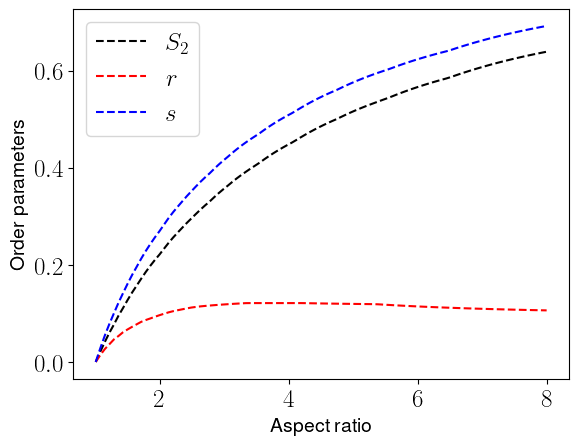

In [5]:
def intepolator(x_data, y_data):
    """
    Generates a 1D linear interpolator from given x and y data.
    """
    interpolator = interp1d(x_data, y_data, kind='linear', fill_value="extrapolate")
    return interpolator

# load data fro biaxiality and s from talbot
biax_no_noise = np.loadtxt('data/r_talbot.csv', delimiter=',', skiprows=0)
s_no_noise = np.loadtxt('data/s_talbot.csv', delimiter=',', skiprows=0)
alpha_lin = np.linspace(1, 8, 100)
beta_lin = (alpha_lin**2 - 1) / (alpha_lin**2 + 1)
biaxiality_talbot = intepolator(biax_no_noise[:, 0], biax_no_noise[:, 1])(beta_lin)
s_talbot = intepolator(s_no_noise[:, 0], s_no_noise[:, 1])(beta_lin)
S2_talbot = s_talbot - biaxiality_talbot / 2 # conversion to S2

plt.plot(alpha_lin, S2_talbot, 'k--', label='$S_2$')
plt.plot(alpha_lin, biaxiality_talbot, 'r--', label='$r$')
plt.plot(alpha_lin, s_talbot, 'b--', label='$s$')
plt.legend()
plt.xlabel('Aspect ratio')
plt.ylabel('Order parameters')

In [6]:
aspect_ratios = np.array(
    [1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 7.0, 8.0])
Is = [0.1]
cofs = np.array([0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0, 100.0])

directory = "data/output_data_hertz"
I = 0.1

# load every (cof, I) once; keys as returned by read_pdf_theta
runs = {(fixed_cof, fixed_I): read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios)
        for fixed_cof in cofs for fixed_I in Is}

# materialize the 4D arrays (cofs, Is, aspect_ratios, ...) with the same names as before
rename_4d = {'phi': 'phis', 'shear_rate': 'shear_rates'}
for name in ['S2_scalar', 'S4_scalar', 'biaxiality', 'theta_d', 'phi',
             'phi_fluctuations', 'D_r', 'shear_rate', 'n1_diff', 'n2_diff',
             'p_yy', 'p_xy', 'S2_tensor', 'S4_tensor', 'omega',
             'theta_bins', 'omega_bins', 'std_omega_bins',
             'tau_r', 'A_infty', 'times', 'oacf',
             'strains', 'S2_over_time', 'angle_over_time', 'biaxiality_over_time']:
    arr = np.array([runs[(fixed_cof, fixed_I)][name]
                    for fixed_cof in cofs for fixed_I in Is])
    globals()[rename_4d.get(name, name)] = arr.reshape(
        (len(cofs), len(Is)) + arr.shape[1:])

# self-consistent theory outputs (cached in a pickle when available)
S2_scalar_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S4_scalar_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U2_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U4_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
JS_divergence = np.zeros((len(cofs), len(Is), len(aspect_ratios)))

loaded = False

try:
    with open(os.path.join(directory, "U_and_rmse_self_consistent.pkl"), 'rb') as f:
        data_loaded = pickle.load(f)
    U1_self_consistents = data_loaded['U1_self_consistents']
    U2_self_consistents = data_loaded['U2_self_consistents']
    rmse_self_consistents = data_loaded['rmse_self_consistents']
    JS_divergence = data_loaded['JS_divergence']

    print("Loaded saved data successfully.")
    loaded = True
except (FileNotFoundError, KeyError):
    print("U_and_rmse_self_consistent.pkl not found or invalid, initializing arrays...")
    U1_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
    U2_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))

for i_cof, fixed_cof in enumerate(cofs):
    for i_I, fixed_I in enumerate(Is):
        run = runs[(fixed_cof, fixed_I)]
        bin_centers, pdf_data = run['bin_centers'], run['pdf_data']
        if not loaded:
            for i_alpha in range(len(aspect_ratios)):
                s2_val = run['S2_scalar'][i_alpha]
                s4_val = run['S4_scalar'][i_alpha]
                phi_val = run['phi'][i_alpha]
                ap = aspect_ratios[i_alpha]

                correction_density = 1.08 * compute_vega_correction_density(ap, phi_val)
                U_theo_2 = correction_density * parsons_volume_approx_p2(ap)
                U_theo_4 = correction_density * parsons_volume_approx_p4(ap)

                K_fitted = find_K_from_S2_S4_p4((s2_val, s4_val),
                                                (U_theo_2, U_theo_4))

                S2_scalar_theoretical[i_cof, i_I, i_alpha], S4_scalar_theoretical[i_cof, i_I, i_alpha] = solve_self_consistent_S2_S4_p4(
                    (U_theo_2, U_theo_4),
                    initial_guesses=(s2_val, s4_val)
                )

                print(
                    f"ap={ap}, U_theo_2={U_theo_2:.3f}, S2_theo={S2_scalar_theoretical[i_cof, i_I, i_alpha]:.3f}")

                if K_fitted < 0.01:
                    K_fitted = np.nan
                U1_self_consistent = K_fitted * U_theo_2
                U2_self_consistent = K_fitted * U_theo_4

                U1_self_consistents[i_cof, i_I, i_alpha] = U1_self_consistent
                U2_self_consistents[i_cof, i_I, i_alpha] = U2_self_consistent

                d_theta = bin_centers[i_alpha, 1] - bin_centers[i_alpha, 0]

                U2_theoretical[i_cof, i_I, i_alpha] = U_theo_2
                U4_theoretical[i_cof, i_I, i_alpha] = U_theo_4

                pdf_theoretical = fit_equilibrium_ODF_P4(
                    bin_centers[i_alpha, :],
                    (S2_scalar_theoretical[i_cof, i_I, i_alpha],
                     S4_scalar_theoretical[i_cof, i_I, i_alpha]),
                    (U_theo_2, U_theo_4)
                )

                JS_divergence[i_cof, i_I, i_alpha] = compute_JS_divergence(
                    pdf_data[i_alpha, :],
                    pdf_theoretical,
                    bin_centers[i_alpha, :])

                rmse_error = compute_rmse_error_p4(
                    pdf_data=pdf_data[i_alpha, :],
                    interaction_params=(U1_self_consistent,
                                        U2_self_consistent),
                    order_params=(s2_val, s4_val),
                    bin_centers=bin_centers[i_alpha, :],
                    bin_width=d_theta,
                    thetas_high_res=thetas_high_res
                )
                rmse_self_consistents[i_cof, i_I, i_alpha] = rmse_error

# save U1_self_consistent and rmse_self_consistent to a pickle file
output_filename = os.path.join(directory, "U_and_rmse_self_consistent.pkl")
with open(output_filename, 'wb') as f:
    pickle.dump({
        'U1_self_consistents': U1_self_consistents,
        'U2_self_consistents': U2_self_consistents,
        'rmse_self_consistents': rmse_self_consistents
    }, f)

U_and_rmse_self_consistent.pkl not found or invalid, initializing arrays...
ap=1.2, U_theo_2=0.254, S2_theo=-0.000
ap=1.5, U_theo_2=1.482, S2_theo=-0.000


/tmp/ipykernel_47779/2665998772.py:261: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  sol = minimize_scalar(objective_func, bounds=(0.0, 7.0),


ap=1.8, U_theo_2=3.260, S2_theo=-0.000
ap=2.0, U_theo_2=4.616, S2_theo=0.499
ap=2.5, U_theo_2=8.295, S2_theo=0.860
ap=3.0, U_theo_2=12.130, S2_theo=0.916
ap=3.5, U_theo_2=15.908, S2_theo=0.940
ap=4.0, U_theo_2=19.523, S2_theo=0.952
ap=4.5, U_theo_2=23.043, S2_theo=0.961
ap=5.0, U_theo_2=26.456, S2_theo=0.966
ap=5.5, U_theo_2=30.054, S2_theo=0.971
ap=6.0, U_theo_2=33.104, S2_theo=0.974
ap=7.0, U_theo_2=41.359, S2_theo=0.979
ap=8.0, U_theo_2=52.334, S2_theo=0.984
ap=1.2, U_theo_2=0.255, S2_theo=-0.000
ap=1.5, U_theo_2=1.481, S2_theo=-0.000
ap=1.8, U_theo_2=3.265, S2_theo=-0.000
ap=2.0, U_theo_2=4.620, S2_theo=0.501
ap=2.5, U_theo_2=8.315, S2_theo=0.861
ap=3.0, U_theo_2=12.123, S2_theo=0.916
ap=3.5, U_theo_2=15.907, S2_theo=0.940
ap=4.0, U_theo_2=19.522, S2_theo=0.952
ap=4.5, U_theo_2=23.089, S2_theo=0.961
ap=5.0, U_theo_2=26.544, S2_theo=0.966
ap=5.5, U_theo_2=29.757, S2_theo=0.970
ap=6.0, U_theo_2=33.432, S2_theo=0.974
ap=7.0, U_theo_2=41.462, S2_theo=0.979
ap=8.0, U_theo_2=51.684, S2_t

ap=1.5, U_theo_2=1.481, U_theo_4=0.018, S2_theo=-0.000, S4_theo=-0.000
ap=2.5, U_theo_2=8.315, U_theo_4=0.336, S2_theo=0.861, S4_theo=0.614
ap=4.0, U_theo_2=19.522, U_theo_4=1.116, S2_theo=0.952, S4_theo=0.850
ap=6.0, U_theo_2=33.432, U_theo_4=2.152, S2_theo=0.974, S4_theo=0.916
ap=8.0, U_theo_2=51.684, U_theo_4=3.464, S2_theo=0.984, S4_theo=0.946
ap=1.5, U_theo_2=1.347, U_theo_4=0.017, S2_theo=-0.000, S4_theo=-0.000


/tmp/ipykernel_47779/2665998772.py:261: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  sol = minimize_scalar(objective_func, bounds=(0.0, 7.0),


ap=2.5, U_theo_2=7.251, U_theo_4=0.293, S2_theo=0.829, S4_theo=0.549
ap=4.0, U_theo_2=15.546, U_theo_4=0.889, S2_theo=0.939, S4_theo=0.810
ap=6.0, U_theo_2=23.597, U_theo_4=1.519, S2_theo=0.962, S4_theo=0.879
ap=8.0, U_theo_2=33.015, U_theo_4=2.213, S2_theo=0.974, S4_theo=0.915
ap=1.5, U_theo_2=0.738, U_theo_4=0.009, S2_theo=-0.000, S4_theo=-0.000
Skipping plot for ap=1.5, bad K fit.
ap=2.5, U_theo_2=3.207, U_theo_4=0.130, S2_theo=-0.000, S4_theo=-0.000
ap=4.0, U_theo_2=6.054, U_theo_4=0.346, S2_theo=0.773, S4_theo=0.453
ap=6.0, U_theo_2=8.760, U_theo_4=0.564, S2_theo=0.877, S4_theo=0.651
ap=8.0, U_theo_2=11.004, U_theo_4=0.738, S2_theo=0.909, S4_theo=0.730


/tmp/ipykernel_47779/986386602.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


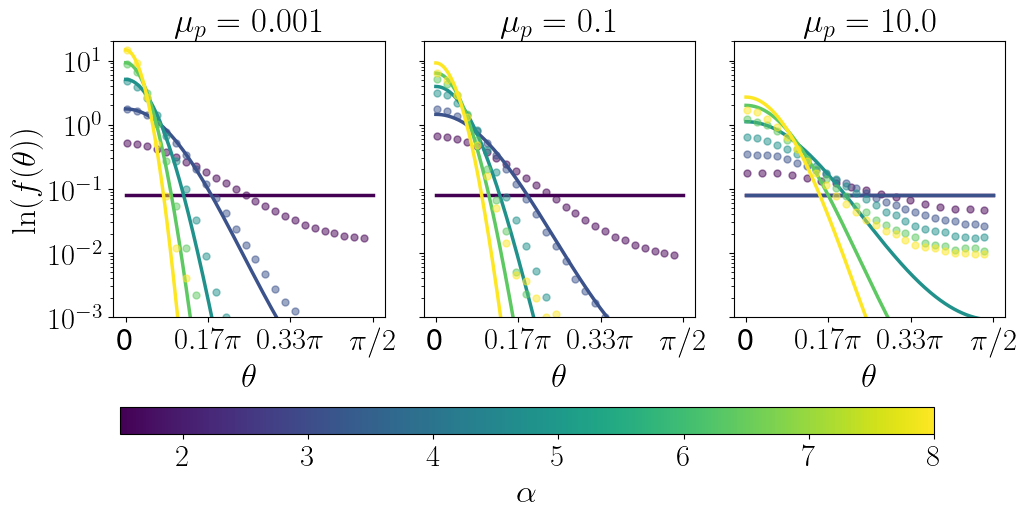

In [39]:
# ODF fits: measured PDF vs theoretical Parsons-Lee ODF
# (same figure as the removed single-pass loader cell, now on the globally loaded data)
odf_alphas = np.array([1.5, 2.5, 4.0, 6.0, 8.0])
odf_cofs = [0.001, 0.1, 10.0]
odf_idx = [int(np.where(aspect_ratios == a)[0][0]) for a in odf_alphas]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

cmap = plt.cm.viridis
num_colors = len(odf_alphas)
delta_color = np.floor(cmap.N / (num_colors - 1))
# assign colors to each aspect ratio
colors = [cmap(i * int(delta_color)) for i in range(num_colors)]

num_cofs = len(odf_cofs)
fig, axes = plt.subplots(1, num_cofs, figsize=(3.5 * num_cofs, 3.5), sharey=True)

if num_cofs == 1:
    axes = [axes]

for ax, cof in zip(axes, odf_cofs):
    i_cof = int(np.where(cofs == cof)[0][0])
    run = runs[(cof, I)]
    bin_centers, pdf_data = run['bin_centers'], run['pdf_data']

    for i, (ap, i_alpha) in enumerate(zip(odf_alphas, odf_idx)):
        s2_val = run['S2_scalar'][i_alpha]
        s4_val = run['S4_scalar'][i_alpha]
        phi_val = phis[i_cof, 0, i_alpha]

        # theoretical U values from Parsons-Lee
        correction_density = 1.08 * compute_vega_correction_density(ap, phi_val)
        U_theo_2 = correction_density * parsons_volume_approx_p2(ap)
        U_theo_4 = correction_density * parsons_volume_approx_p4(ap)

        S2_theo, S4_theo = solve_self_consistent_S2_S4_p4(
            (U_theo_2, U_theo_4), initial_guesses=(s2_val, s4_val))

        print(f"ap={ap}, U_theo_2={U_theo_2:.3f}, U_theo_4={U_theo_4:.3f}, "
              f"S2_theo={S2_theo:.3f}, S4_theo={S4_theo:.3f}")

        # scaling factor K from the measured order parameters
        K_fitted = find_K_from_S2_S4_p4((s2_val, s4_val), (U_theo_2, U_theo_4))
        if K_fitted < 0.01:
            K_fitted = np.nan
        U_params = (K_fitted * U_theo_2, K_fitted * U_theo_4)

        theo_odf = fit_equilibrium_ODF_P4(thetas_high_res, (S2_theo, S4_theo),
                                          (U_theo_2, U_theo_4))

        # bad fits (NaNs)
        if np.isnan(U_params[0]):
            ax.semilogy(bin_centers[i_alpha, ::6], pdf_data[i_alpha, ::6], 'o',
                        linestyle='', markersize=5, color=colors[i], alpha=0.5)
            ax.semilogy(thetas_high_res, theo_odf, label=f'$\\alpha={ap}$',
                        linestyle='-', linewidth=2.5, color=colors[i])
            print(f"Skipping plot for ap={ap}, bad K fit.")
            continue

        # plot PDF data and theoretical ODF
        ax.semilogy(bin_centers[i_alpha, ::4], pdf_data[i_alpha, ::4], 'o',
                    linestyle='', markersize=5, color=colors[i], alpha=0.5)
        ax.semilogy(thetas_high_res, theo_odf, linestyle='-', linewidth=2.5,
                    color=colors[i], alpha=1.0)

    ax.set_xlabel('$\\theta$', fontsize=24)
    ax.set_title(f'$\\mu_p = {cof}$', fontsize=25)
    ax.set_ylim(1e-3, 20)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))

# normalize aspect_ratios (alpha values) to [0, 1] range for colormap
norm = mcolors.Normalize(vmin=min(odf_alphas), vmax=max(odf_alphas))
sm = cm.ScalarMappable(cmap='viridis', norm=norm)  # use your same colormap
sm.set_array([])  # Needed only for matplotlib < 3.1

# add colorbar below the subplots
cbar = plt.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.3,
                    aspect=30, anchor=(0.5, -2.5))
cbar.set_label(r'$\alpha$', fontsize=24)
cbar.ax.tick_params(labelsize=22)

# set common Y label
axes[0].set_ylabel('$\\ln(f(\\theta))$', fontsize=24)

# make all tick labels larger
for ax in axes:
    ax.tick_params(axis='both', labelsize=22)

plt.tight_layout()
plt.show()

In [8]:
corrections_densities = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
for i_cof, fixed_cof in enumerate(cofs):
    for i_I, fixed_I in enumerate(Is):
        for i_alpha, alpha_val in enumerate(aspect_ratios):
            phi_val = phis[i_cof, i_I, i_alpha]
            corrections_densities[i_cof, i_I, i_alpha] = 1.08 * compute_vega_correction_density(alpha_val, phi_val)

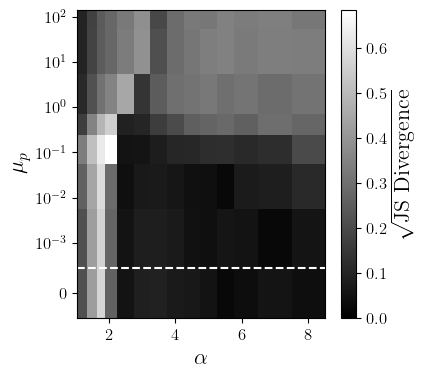

In [9]:
X, Y = np.meshgrid(aspect_ratios, cofs) 
plot_data = np.sqrt(JS_divergence[:, 0, :])
vmax_val = np.nanmax(plot_data)

# --- Create the plot ---
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Use pcolormesh for non-uniform grids
im = ax.pcolormesh(X, Y, plot_data, 
                   cmap='gray', 
                   vmin=0, 
                   vmax=vmax_val,
                   shading='auto') # 'shading' is important

# --- Set the y-axis to 'symlog' ---
ax.set_yscale('symlog', linthresh=0.001)
ax.axhline(y=0.0005, color='white', linestyle='--', linewidth=1.5)  # Example threshold line
# --- Add labels and colorbar ---
cbar = fig.colorbar(im, ax=ax)
# Make sure the label matches the data you're plotting
cbar.set_label(r'$\sqrt{\mathrm{JS\;Divergence}}$', fontsize=16) 
ax.set_xlabel(r'$\alpha$', fontsize=16)
ax.set_ylabel(r'$\mu_p$', fontsize=16)
fig.savefig(f"Figures/js_divergence_p4_Is_{Is[0]}.pdf", dpi=300, bbox_inches='tight')
# ax.set_title('JS Divergence between Measured PDF and Self-Consistent P2+P4 ODF', fontsize=18)

U_experimental self consistent: [4.48641904 5.70109597 7.09517206]


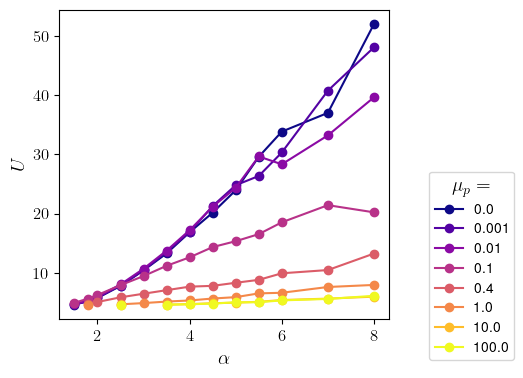

In [10]:
# plot the biaxiality as a function of aspect ratio for different cof and Is
cmap = plt.cm.plasma
num_cofs = len(cofs)

# U_experimental = np.array([1.2512, 4.108, 5.747])
alpha_experimental= np.array([2.0, 3.3, 5.0])
phi_experimental = np.array([0.495, 0.5, 0.48])
S2_experimental = np.array([0.27, 0.72, 0.81])

U_experimental = np.array([find_U_from_S2(s2) for s2 in S2_experimental])
print("U_experimental self consistent:", U_experimental)

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(6,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    volume = 4*np.pi*aspect_ratios/3 
   
    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        plt.plot(
            aspect_ratios,
            U1_self_consistents[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

        # fir alpha **2parabola
        def parabola_fit(alpha, a, b, c):
            return a * alpha**b + c

    plt.xlabel(f"$\\alpha$")
    plt.ylabel("$U $")#\\phi$")
    plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 0.5), fontsize=10)
    plt.tight_layout()
    plt.show()

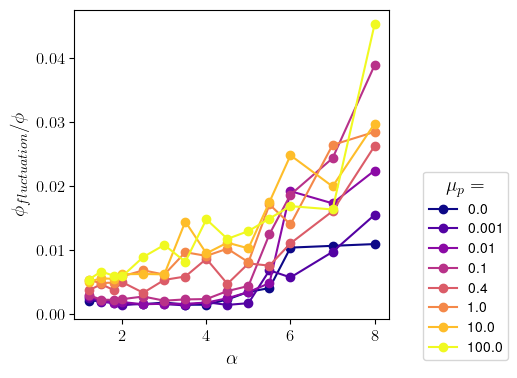

In [11]:
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(6,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    volume = 4*np.pi*aspect_ratios/3 
   
    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        plt.plot(
            aspect_ratios,
            phi_fluctuations[i_cof, i_I, :] / phis[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

    plt.xlabel(f"$\\alpha$")
    plt.ylabel("$\\phi_{fluctuation}/\\phi$")
    plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 0.5), fontsize=10)
    plt.tight_layout()
    plt.show()

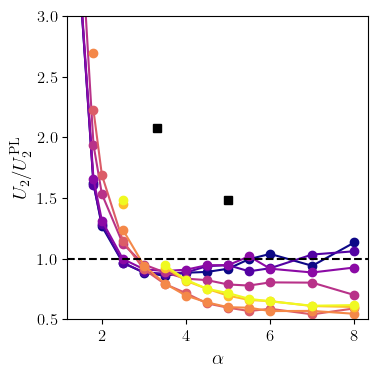

In [12]:
U1_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U2_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))

colors_cof = cmap(np.linspace(0, 1, num_cofs))
cmap = mcolors.ListedColormap(colors_cof)

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    volume = 4*np.pi*aspect_ratios/3 
    volume_excluded = parsons_volume_approx_p2(aspect_ratios)
    volume_excluded_p4 = parsons_volume_approx_p4(aspect_ratios)


    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        number_density = phi_dense / volume
        correction_density = compute_correction_density(phi_dense)
        U1_theoretical[i_cof, i_I, :] = volume_excluded * correction_density * 1.08
        U2_theoretical[i_cof, i_I, :] = volume_excluded_p4 * correction_density * 1.08
        plt.plot(
            aspect_ratios,
            U1_self_consistents[i_cof, i_I, :] / U1_theoretical[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

    
    correction_density_experimental = phi_experimental * (1-3/4*phi_experimental) / (1-phi_experimental)**2
    volume_excluded_experimental = -excluded_volume_rod(alpha_experimental)
    plt.plot(
        alpha_experimental,
        U_experimental / (volume_excluded_experimental * correction_density_experimental),
        's',
        label='Experimental data',
        color='black'
    )

    norm = mcolors.Normalize(vmin=-0.5, vmax=num_cofs - 0.5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

    # Create the colorbar and place ticks exactly at the integer centers
    cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(num_cofs), orientation='vertical', 
                        fraction=0.05, pad=0.02)

    #  Replace the integer labels with your actual 'cofs' values
    cbar.ax.set_yticklabels([str(c) for c in cofs])
    cbar.set_label(r'$\mu_p$', fontsize=16)
    cbar.ax.tick_params(labelsize=12)
    
    plt.xlabel(f"$\\alpha$")
    plt.ylabel("$U_2 / U_2^{{\\mathrm{PL}}}$")
    plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    plt.ylim(0.5, 3.0)
    plt.tight_layout()
    # plt.savefig(f"Figures/U_fitted_scaled_vs_alpha.pdf", dpi=300, bbox_inches='tight')
    plt.show()

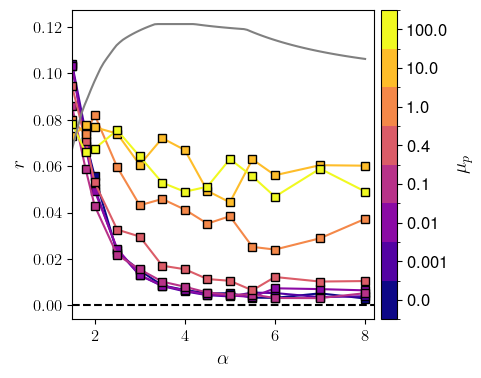

In [13]:
alphas_rods_experiments = np.array([2.0, 3.3,5.0]) #from alignment and dynamics Soft matter 2012

biaxiality_data_rods_experiments = np.array([0.21, 0.12, 0.09]) #taken from shear zone core 10-30
biaxiality_data_rods_experiments *= 2/3 # to convert to biaxiality as defined here

theta_d_rods_experiments = np.array([10.1, 8.0, 6.3])
# theta_d_rods_experiments = np.deg2rad(theta_d_rods_experiments)  # Convert degrees to radians

cmap = plt.cm.plasma
for i_I, I_val in enumerate(Is):
    fig = plt.figure(figsize=(5,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):
        plt.plot(
            aspect_ratios,
            biaxiality[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='s',
            markeredgecolor='black'
        )
    
    # Plot Jeffrey's prediction
    plt.plot(alpha_lin, biaxiality_talbot, '-', color='gray', label="Jeffrey's prediction")

    # Plot experimental data
    # plt.plot(alphas_rods_experiments, biaxiality_data_rods_experiments, 's', color='black', label='Experiments (rods)')

    cmap_discrete = mcolors.ListedColormap(colors_cof)

    bounds = np.arange(len(cofs) + 1)
    norm = mcolors.BoundaryNorm(bounds, cmap_discrete.N)

    sm = cm.ScalarMappable(cmap=cmap_discrete, norm=norm)
    sm.set_array([]) # Required for matplotlib <= 3.1, safe to leave in

    cbar = fig.colorbar(sm, ax=plt.gca(), pad=0.02)

    cbar.set_ticks(np.arange(len(cofs)) + 0.5)
    cbar.set_ticklabels([str(val) for val in cofs])
    cbar.set_label("$\\mu_p$")

    plt.xlabel("$\\alpha$")
    plt.ylabel("$r$")
    plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Uniaxial limit")
    plt.tight_layout()
    plt.xlim(1.5, 8.2)
    plt.savefig(f"Figures/biaxiality_vs_alpha_I_{I_val}.pdf", dpi=300, bbox_inches='tight')
    plt.show()



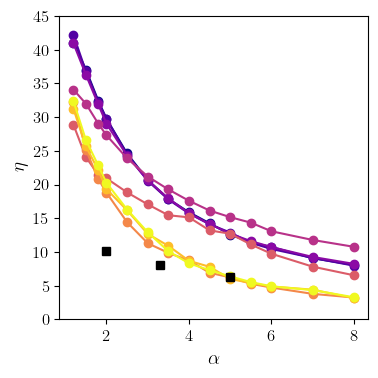

In [14]:
# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    

    for i_cof, cof_val in enumerate(cofs):
        theta_shifted = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted*180/np.pi,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
      
    # Plot experimental data
    plt.plot(alphas_rods_experiments, theta_d_rods_experiments, 's', color='black', label='Experiments (rods)')


    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$")
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(1.1, 1.0), fontsize=10)
    # plt.grid(True)
    plt.ylim([0., 45])
    plt.tight_layout()
    plt.savefig(f"Figures/theta_d_vs_alpha_I_{I_val}.svg", dpi=300, bbox_inches='tight')
    plt.show()



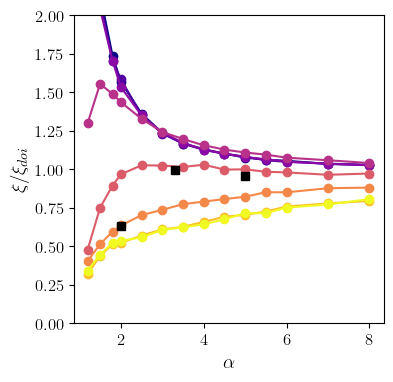

In [15]:
# derive lambda from theta_d and beta and plot it as a fucntion of alpha for the different parameters

# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):

        c = np.tan(theta_d[i_cof, i_I, :])**2
        ell = (+1 + c) / (1-c)
        beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
        nematic_factor = (2+S2_scalar[i_cof, i_I, :])/(3*S2_scalar[i_cof, i_I, :])
        lambda_derived = nematic_factor
        eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)
        plt.plot(
            aspect_ratios,
            # ell/beta,
            ell/lambda_derived,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
        doi_theory_lambda = beta*(2 + S2_scalar[i_cof, i_I, :]) 

    # plot experimental data
    eccentricity_experimental = np.sqrt(1 - 1 / alphas_rods_experiments**2)
    c_experimental = np.tan(np.deg2rad(theta_d_rods_experiments))**2
    ell_experimental = (+1 + c_experimental) / (1-c_experimental)
    beta_experimental = (alphas_rods_experiments**2 - 1) / (alphas_rods_experiments**2 + 1)
    nematic_factor_experimental = (2+S2_experimental)/(3*S2_experimental)
    lambda_derived_experimental = beta_experimental * nematic_factor_experimental
    plt.plot(
        alphas_rods_experiments,
        # ell_experimental/beta_experimental,
        ell_experimental/lambda_derived_experimental,
        's',
        color='black',
        label='Experiments (rods)'
    )    
    

    # plt.title(f"Ericksen number vs epsilon for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\xi / \\xi_{doi}$")
    # plt.legend(title="$\\mu_p =$")
    # plt.grid(True)
    plt.ylim([0., 2])
    # plt.tight_layout()
    plt.savefig(f"Figures/ericksen_number_vs_epsilon_I_{I_val}.svg", dpi=300, bbox_inches='tight')
    plt.show()



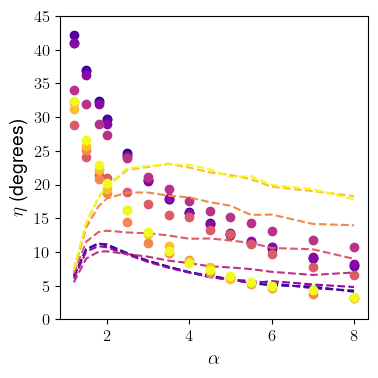

In [16]:
# compare the director angle predicted by doi theory to the measured one

theta_doi = np.zeros_like(theta_d)
for i_cof, cof_val in enumerate(cofs[:]):
    for i_I, I_val in enumerate(Is):
        for i_alpha, alpha_val in enumerate(aspect_ratios):
            beta = (alpha_val**2 - 1) / (alpha_val**2 + 1)
            S2 = S2_scalar[i_cof, i_I, i_alpha]
            nematic_factor = (2 + S2) / (3 * S2)
            lambda_doi =  nematic_factor
            lambda_higher = beta * (6 + S2 + 8 * S2**2) / (15 * S2)
            theta_doi[i_cof, i_I, i_alpha] = beta * np.arctan( np.sqrt( (lambda_doi - 1) / (lambda_doi + 1) ) )
            # theta_doi[i_cof, i_I, i_alpha] = np.arctan( np.sqrt( (lambda_higher - 1) / (lambda_higher + 1) ) )


for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs[:]):
        theta_shifted_measured = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        theta_shifted_doi = np.where(theta_doi[i_cof, i_I, :] < 0, theta_doi[i_cof, i_I, :] + np.pi, theta_doi[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted_measured*180/np.pi,
            label=f"Measured $\\mu_p={cof_val}$",
            color=colors[i_cof],
            marker='o', 
            linestyle= 'none'
        )
        plt.plot(
            aspect_ratios,
            theta_shifted_doi*180/np.pi,
            label=f"DOI Theory $\\mu_p={cof_val}$",
            color=colors[i_cof],
            linestyle='--'
        )
    
    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$ (degrees)")
    plt.ylim([0., 45])
    # plt.legend(bbox_to_anchor=(1.05, 1.0), fontsize=10)
    plt.tight_layout()
    # plt.savefig(f"Figures/theta_doi_vs_measured_vs_alpha_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



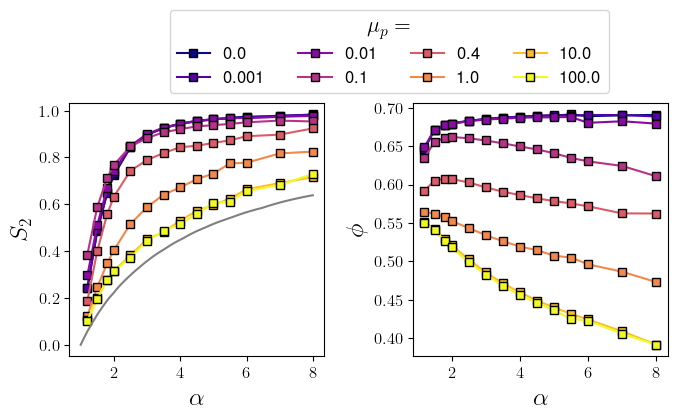

In [17]:
# plot phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 2, figsize=(7,4*7/8))
for i_cof, cof_val in enumerate(cofs):
    ax[1].plot(
        aspect_ratios,
        phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='s',
        markeredgecolor='black',
    )
    ax[0].plot(
        aspect_ratios,
        S2_scalar[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='s',
        markeredgecolor='black',
    )

ax[0].set_xlabel(f"$\\alpha$", fontsize=18)
ax[0].set_ylabel("$S_2$", fontsize=18)
ax[0].plot(alpha_lin, S2_talbot, '-', color='gray', label="Jeffrey's prediction")
ax[1].set_xlabel(f"$\\alpha$", fontsize=18)
ax[1].set_ylabel("$\\phi$", fontsize=18)
fig.tight_layout()
plt.legend(title="$\\mu_p=$", bbox_to_anchor=(0.8, 1.4), fontsize=12, ncols=4, title_fontsize=16)
plt.savefig(f"Figures/S2_phi_vs_alpha_I_{I}.svg", dpi=300, bbox_inches='tight')

Slope (frictionless): -2.208165634516121, Intercept: -0.13915825565395784
Slope (frictional): -1.4108553992639903, Intercept: -0.7767665525246067
Power law fit parameters frictional: a = 0.4917967224356915, b = -1.3050231792388276


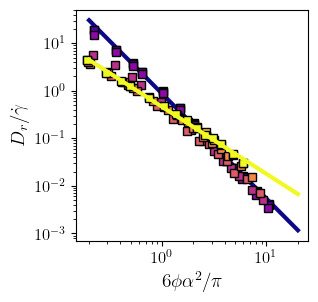

In [18]:
# Power law model: y = a * x^b
def power_law(x, a, c):
    return a *x**c

cmap = plt.cm.plasma
colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]

n_ell_fit = np.linspace(2*10**(-1), 2*10**1, 100)

# plot the D_r over shear rate as function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
Dr_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
max_nell = 0
for i_cof, cof_val in enumerate(cofs):
    V_p = 4 * np.pi * aspect_ratios / 3  # particle volume for prolate ellipsoid
    n_ell3 = phis[i_cof, 0, :] / V_p *aspect_ratios**3
    nem_param = S2_scalar[i_cof, 0, :]
    correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * nem_param**2

    max_nell = max(max_nell, np.max(n_ell3))

    ax.loglog(
        n_ell3[:],
        D_r[i_cof, 0, :] * correction_end_end_contact[:]**2/shear_rates[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors[i_cof],
        markeredgecolor='black',
    )

    log_nell3 = np.log(n_ell3[:])  # Exclude first three points to avoid low-n_ell deviations
    log_Dr_over_shear = np.log(D_r[0, 0, :] * correction_end_end_contact[:]**2 / shear_rates[0, 0, :])

    if cof_val == 0.0:
        # Fit the data
        slope, intercept = np.polyfit(log_nell3, log_Dr_over_shear, 1)
        print(f"Slope (frictionless): {slope}, Intercept: {intercept}")

        popt, _ = spo.curve_fit(
            power_law,
            n_ell3[3:],
            D_r[0, 0, 3:] * correction_end_end_contact[3:]**2 / shear_rates[0, 0, 3:],
            p0=[0,0]  # Initial guess for a and b
        )

        # plot fit performed in log log scale
        ax.loglog(
           n_ell_fit,
           np.exp(intercept) * np.exp(slope * np.log(n_ell_fit)),
           '-',
           label='Power law fit (frictionless)',
           linewidth=3,
           color=colors[i_cof]
        )              

    
    if cof_val == 100.0:
        popt_frictional, _ = spo.curve_fit(
            power_law,
            n_ell3[:],
            D_r[i_cof, 0, :] * correction_end_end_contact[:]**2 / shear_rates[i_cof, 0, :],
            p0=[0,0]  # Initial guess for a and b
        )
        slope_frictional, intercept_frictional = np.polyfit(log_nell3, np.log(D_r[i_cof, 0, :] * correction_end_end_contact[:]**2 / shear_rates[i_cof, 0, :]), 1)
        print(f"Slope (frictional): {slope_frictional}, Intercept: {intercept_frictional}")
    
        ax.loglog(
            n_ell_fit,  
            np.exp(intercept_frictional) * np.exp(slope_frictional * np.log(n_ell_fit)),
            '-',
            label='Power law fit (frictional)',
            linewidth=3,
            color=colors[i_cof],
            markeredgecolor='black',
          )
    Dr_theoretical[i_cof, 0, :] = power_law(n_ell3, *popt) * shear_rates[i_cof, 0, :] / correction_end_end_contact**2


correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * S2_scalar[0,0,:]**2
print(f"Power law fit parameters frictional: a = {popt_frictional[0]}, b = {popt_frictional[1]}")

ax.set_xlabel("$6 \\phi \\alpha^2 / \\pi$")
ax.set_ylabel("$D_{r}/ \\dot \\gamma$")
fig.savefig(f"Figures/D_r_over_shear_vs_n_ell3_I_{I}.svg", dpi=300, bbox_inches='tight')

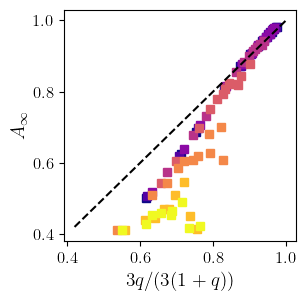

In [19]:
# plot the D_r over shear rate as function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
for i_cof, cof_val in enumerate(cofs):
    q_chen = U1_self_consistents[i_cof, 0, :] / 3 * S2_scalar[i_cof, 0, :] * (S2_scalar[i_cof, 0, :] + 0.5)
    ax.plot(
        (3 * q_chen + 1) / (3 * (1 + q_chen)), 
        A_infty[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors[i_cof]
    )

ax.plot([0.42, 1], [0.42, 1], '--', color='black', label='y=x')

ax.set_xlabel("$3 q / (3(1+q))$")
ax.set_ylabel("$A_{\\infty}$")
fig.savefig(f"Figures/A_infty_I_{I}.pdf", dpi=300, bbox_inches='tight')

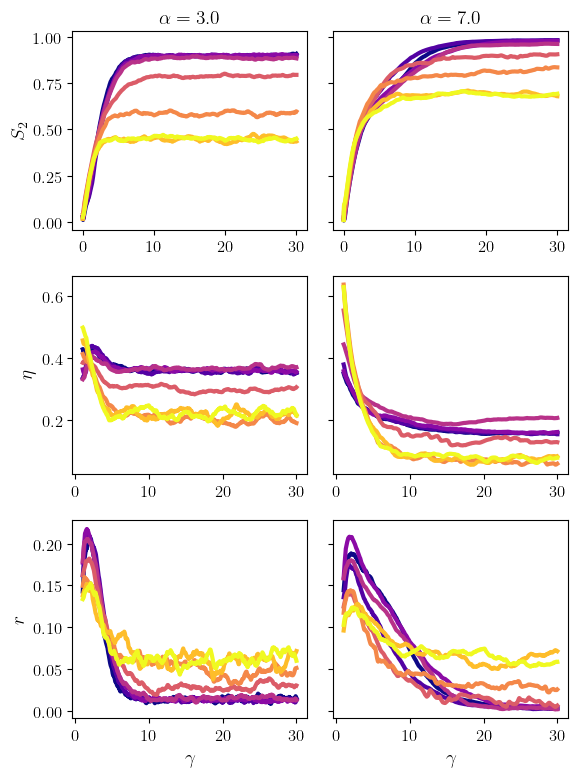

In [20]:
# plot s2 over time for a fixd alpha and different cofs
alpha_indexs = [5, 12]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]


fig, ax = plt.subplots(3, len(alpha_values), figsize=(3*len(alpha_values), 8), sharey='row')
for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs):
        # remove trailing zeros to arrays
        gamma = strains[i_cof, 0, alpha_index, :]
        S2_t = S2_over_time[i_cof, 0, alpha_index, :]
        biaxiality_t = biaxiality_over_time[i_cof, 0, alpha_index, :]
        eta = angle_over_time[i_cof, 0, alpha_index, :]

        gamma = np.where(gamma != 0, gamma, np.nan)  # Replace zeros with NaN for better plotting
        S2_t = np.where(S2_t != 0, S2_t, np.nan)  # Replace zeros with NaN for better plotting
        eta = np.where(eta != 0, eta, np.nan)
        biaxiality_t = np.where(biaxiality_t != 0, biaxiality_t, np.nan)

        ax[0][i].plot(
            gamma,
            S2_t,
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3
        )

        ax[1][i].plot(
            gamma[100:],
            eta[100:],
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3
        )

        ax[2][i].plot(
            gamma[100:],
            biaxiality_t[100:],
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3
        )


    ax[0, i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[2, i].set_xlabel("$\\gamma$")

ax[0, 0].set_ylabel("$S_2$")
ax[1, 0].set_ylabel("$\\eta$")
ax[2, 0].set_ylabel("$r$")
fig.tight_layout()
fig.savefig(f"Figures/S2_over_time_vs_gamma_alpha.pdf", dpi=600, bbox_inches='tight')

<>:52: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_47779/3426190129.py:52: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel("$\langle [\mathbf{u}(\\gamma) \cdot \mathbf{u}(0)]^2  \\rangle  $")


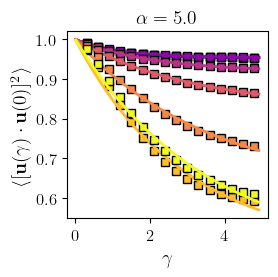

In [21]:
# plot oacf over time

def model_decay(t, tau_r, A_infty):
    return A_infty + (1 - A_infty) * np.exp(-t / tau_r)

alpha_indexs = [9]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(3*n_plots, 3), sharey=True)

if n_plots == 1:
    ax = [ax]

for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        i_cof = np.where(cofs == cof_val)[0][0]

        t = times[i_cof, 0, alpha_index, :]
        gamma = shear_rates[i_cof, 0, alpha_index] * t
        corr = oacf[i_cof, 0, alpha_index, :]

        t = np.where(t != 0, t, np.nan)  # Replace zeros with NaN for better plotting
        corr = np.where(corr != 0, corr, np.nan)  # Replace zeros with NaN for better plotting
        gamma = np.where(gamma != 0, gamma, np.nan)

        ax[i].plot(
            gamma[::30],
            corr[::30],
            's',
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            markeredgecolor='black'

        )
        # plot the fitted model
        ax[i].plot(
            gamma, 
            model_decay(gamma/shear_rates[i_cof, 0, alpha_index], tau_r[i_cof, 0, alpha_index], A_infty[i_cof, 0, alpha_index]),
            color=colors_cof[i_cof],
            linestyle='-',
            linewidth=2,
        )

    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    # ax[i].set_xlabel("$t$")
    ax[i].set_xlabel("$\\gamma$")

ax[0].set_ylabel("$\langle [\mathbf{u}(\\gamma) \cdot \mathbf{u}(0)]^2  \\rangle  $")
fig.tight_layout()
fig.savefig(f"Figures/oacf_vs_time_alpha.svg", dpi=300, bbox_inches='tight')


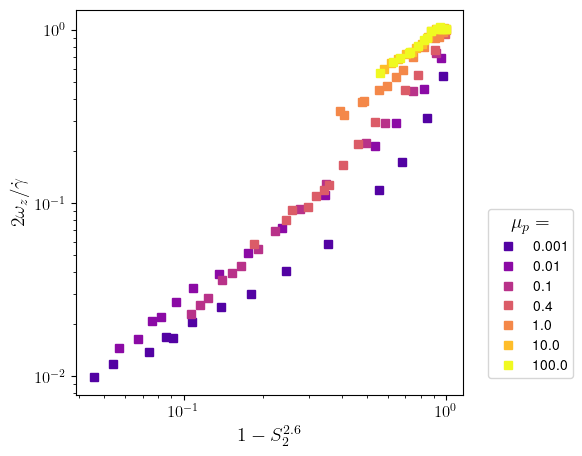

In [22]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    if i_cof <= 0.0:
        continue
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_angle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 
    nematic_screening = 2 / 3 * (1-S2_scalar[i_cof, 0, :])
    ax.loglog(
        1-S2_scalar[i_cof, 0, :]**2.6,
        - 2 * omega[i_cof, 0, :, 2] / shear_rates[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )

ax.set_xlabel("$1-S_{2}^{2.6}$")
ax.set_ylabel(r"$2 \omega_z / \dot \gamma$")
ax.legend(title ="$\\mu_p=$", bbox_to_anchor=(1.3, 0.5), fontsize=10)
fig.savefig(f"Figures/pol_scaling_dimensionless_no_mup0.pdf", dpi=300, bbox_inches='tight')

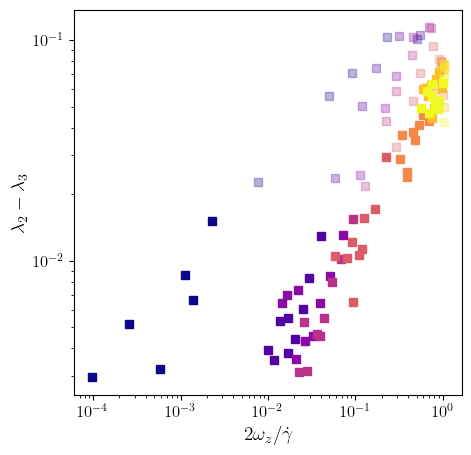

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_amgle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 

    ax.loglog(
        -2*omega[i_cof, 0, 5:, 2]/shear_rates[i_cof, 0, 5:], 
        biaxiality[i_cof, 0, 5:],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )

    ax.loglog(
        -2*omega[i_cof, 0, :5, 2] /shear_rates[i_cof, 0, :5], 
        biaxiality[i_cof, 0, :5],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof], 
        alpha=0.3
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$2\\omega_z/ \\dot\\gamma$")
ax.set_ylabel("$\\lambda_2- \\lambda_3$")
# ax.axhline(0.5, color='k', linestyle='--', linewidth=1.5, label="Maximum biaxiality")
# plt.xlim(0.001, 3.0)
# ax.set_ylim(0, 100)
fig.savefig(f"Figures/biaxiality_vs_omega.pdf", dpi=300, bbox_inches='tight')

In [24]:
S2_scalar_theoretical[S2_scalar_theoretical <0] = 0.0
S4_scalar_theoretical[S4_scalar_theoretical <0] = 0.0


<>:134: SyntaxWarning: invalid escape sequence '\m'
<>:134: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_47779/1983654731.py:134: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$\mu_p$', fontsize=18)


Starting individual fits (4-parameter model)...


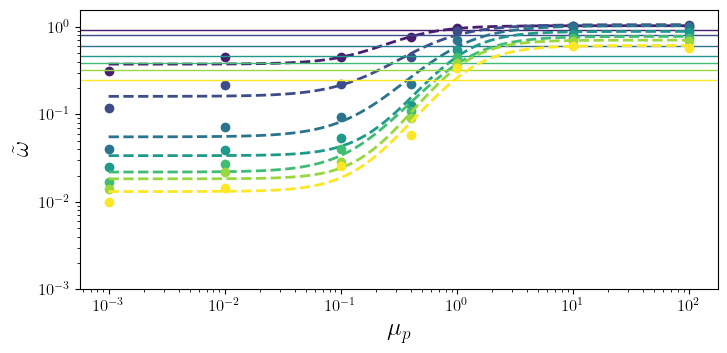


--- All Fit Parameters [A, B, mu_c, k] ---
Alpha  1.2: [0.511, 1.052, 0.065, 0.564]
Alpha  1.5: [0.376, 1.032, 0.315, 1.790]
Alpha  1.8: [0.225, 1.040, 0.466, 1.595]
Alpha  2.0: [0.161, 1.061, 0.556, 1.591]
Alpha  2.5: [0.082, 1.056, 0.753, 1.602]
Alpha  3.0: [0.055, 1.031, 0.887, 1.630]
Alpha  3.5: [0.040, 0.943, 0.994, 1.669]
Alpha  4.0: [0.034, 0.888, 1.014, 1.945]
Alpha  4.5: [0.027, 0.830, 1.051, 1.868]
Alpha  5.0: [0.022, 0.779, 1.079, 1.739]
Alpha  5.5: [0.019, 0.767, 1.240, 1.671]
Alpha  6.0: [0.018, 0.706, 1.058, 2.004]
Alpha  7.0: [0.014, 0.665, 1.160, 1.894]
Alpha  8.0: [0.013, 0.613, 1.210, 1.861]


In [25]:
from scipy.optimize import curve_fit

# --- Define the 5-Parameter Model for a single alpha ---
def simplified_model(mu_p, A, B, mu_c, k):
    """
    Fits the data for a single, fixed alpha.
    y = (1-S) * A + S * B
    
    Parameters to fit:
    A:    Screening plateau (low mu_p)
    B:    Gearing plateau (high mu_p)
    mu_c: Critical friction
    k:    Steepness of switch
    """
    
    mu_p_safe = mu_p + 1e-9
    mu_c_safe = mu_c + 1e-9
    
    screening_state = A
    gearing_state = B  # Simplified: gearing state is a plateau
    
    # Numerically stable switch
    mu_ratio = mu_p_safe / mu_c_safe
    switch = 1.0 / (1.0 + mu_ratio**(-k))
    
    return (1.0 - switch) * screening_state + switch * gearing_state

def simplified_model_k_fixed(mu_p, A, B, mu_c):
    """
    Fits the data for a single, fixed alpha.
    y = (1-S) * A + S * B
    
    Parameters to fit:
    A:    Screening plateau (low mu_p)
    B:    Gearing plateau (high mu_p)
    mu_c: Critical friction
    k:    Steepness of switch fixed at 2.5
    """
    
    mu_p_safe = mu_p + 1e-9
    mu_c_safe = mu_c + 1e-9
    
    screening_state = A
    gearing_state = B  # Simplified: gearing state is a plateau
    
    # Numerically stable switch
    mu_ratio = mu_p_safe / mu_c_safe
    switch = 1.0 / (1.0 + mu_ratio**(-1.75))
    
    return (1.0 - switch) * screening_state + switch * gearing_state

def log_model(mu_p, A, B, mu_c, k):
    return np.log(simplified_model(mu_p, A, B, mu_c, k))

def log_model_k_fixed(mu_p, A, B, mu_c):
    return np.log(simplified_model_k_fixed(mu_p, A, B, mu_c))


mu_p_values = cofs

all_fit_parameters = {}
error_bars = {}

plt.figure(figsize=(10*.75, 5*.75))
ax = plt.gca()
colors = plt.cm.viridis(np.linspace(0, 1, len(aspect_ratios)))

betas = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
y_data_2d = - 2 * omega[1:, 0, :, 2] / shear_rates[1:, 0, :] # / np.sqrt(1 - betas**2)
print("Starting individual fits (4-parameter model)...")

# --- Loop, Fit, and Plot ---
for i_alpha, alpha_val in enumerate(aspect_ratios[:]):
    
    x_data_fit = mu_p_values[1:]
    y_data_fit = np.log(y_data_2d[:, i_alpha])
    
    # --- Perform the Fit ---
    # Guesses [A, B, mu_c, k]
    A_guess = max(y_data_fit[0], 1e-9)
    B_guess = max(y_data_fit[-1], 1e-9)

    # Bounds for A must be positive
    bounds = ([1e-9, 1e-9, 1e-9, 1e-9], [np.inf, np.inf, 5.0, 10.0]) 
    p0 = [A_guess, B_guess, 0.5, 2.5]
    
    
    try:
        popt, pcov = curve_fit(
            log_model,
            # log_model,
            x_data_fit,
            y_data_fit,
            p0=p0,
            bounds=bounds,
            maxfev=5000
        )
        all_fit_parameters[alpha_val] = popt
        perr = np.sqrt(np.diag(pcov))
        error_bars[alpha_val] = perr
        
        mu_fit_line = np.logspace(-3, np.log10(mu_p_values.max()), 100)
        y_vals_fit = log_model(mu_fit_line, *popt)
        # y_vals_fit = log_model(mu_fit_line, *popt)


    except RuntimeError as e:
        print(f"Fit failed for alpha = {alpha_val:.2f}: {e}")
        all_fit_parameters[alpha_val] = [np.nan] * 4
    
    if (i_alpha+1)%2 == 0:
        # Plot original data
        ax.plot(
            x_data_fit, 
            np.exp(y_data_fit), 
            'o', 
            color=colors[i_alpha], 
            label=f"${alpha_val:.1f}$"
        )
        ax.plot(mu_fit_line, np.exp(y_vals_fit), '--', color=colors[i_alpha], linewidth=2)

        # plot jeffrey theory value
        omega_jeffrey =  np.sqrt(1 - betas[i_alpha]**2)
        ax.axhline(
            omega_jeffrey,
            color=colors[i_alpha],
            linestyle='-',
            linewidth=1.0
        )

# --- Finalize Plot ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$\mu_p$', fontsize=18)
# ax.set_ylabel(r'$-2\langle\omega\rangle / \dot{\gamma}$', fontsize=18)
ax.set_ylabel(r'$\tilde{\omega}$', fontsize=18)
ax.set_ylim(0.001, y_data_2d.max()*1.5)

plt.tight_layout()
plt.savefig("Figures/omega_fit_vs_mu_p.png", dpi=300, bbox_inches='tight', transparent=True)
# plt.xlim(0, 0.01)
plt.show()

# --- Print Stored Parameters ---
print("\n--- All Fit Parameters [A, B, mu_c, k] ---")
for alpha_val, params in all_fit_parameters.items():
    param_str = ", ".join([f"{p:.3f}" for p in params])
    print(f"Alpha {alpha_val:4.1f}: [{param_str}]")

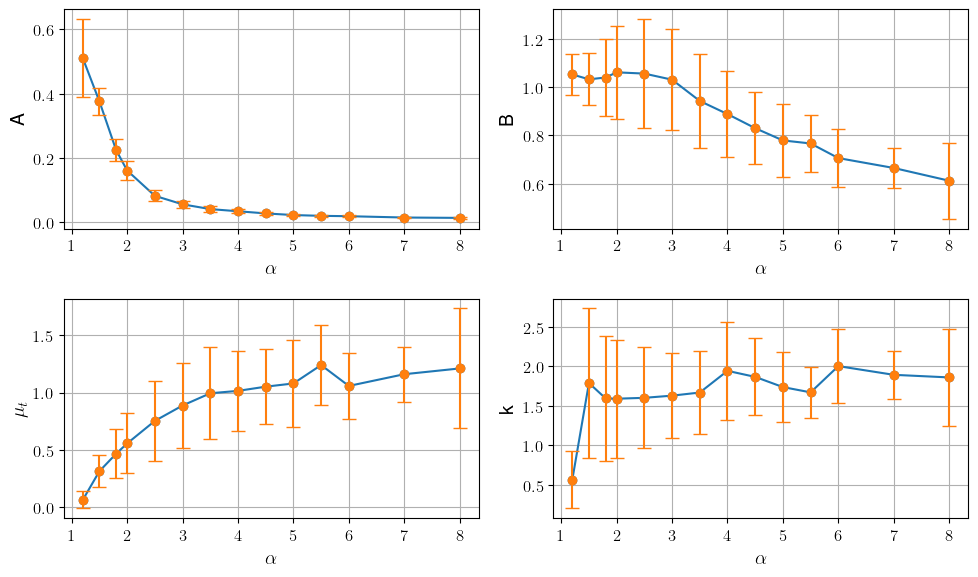

In [26]:
# plot fitted parameters as a function of aspect ratio
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
for i, param_name in enumerate(['A', 'B', r'$\mu_t$', 'k']):
# for i, param_name in enumerate(['A', 'B']):
    ax_i = ax[i // 2, i % 2]
    param_values = [all_fit_parameters[alpha][i] for alpha in aspect_ratios[:]]
    betas = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
    ax_i.plot(
        aspect_ratios[:],
        # betas[1:],
        param_values,
        'o-'
    )

    # add error bars
    error_values = [error_bars[alpha][i] for alpha in aspect_ratios[:]]
    ax_i.errorbar(
        aspect_ratios[:],
        param_values,
        yerr=error_values,
        fmt='o',
        capsize=5,
        # color='blue'
    )

    ax_i.set_xlabel('$\\alpha$')
    ax_i.set_ylabel(param_name)
    ax_i.grid(True)

plt.tight_layout()
plt.savefig("Figures/fit_parameters_vs_alpha.pdf", dpi=300, bbox_inches='tight')

In [27]:
all_fit_parameters_array = np.array(
    [all_fit_parameters[alpha] for alpha in aspect_ratios[:]]
)
print("Fit parameters array shape:", all_fit_parameters_array.shape)
# print("average k value over alphas:", np.nanmean(all_fit_parameters_array[:, 3]))

Fit parameters array shape: (14, 4)


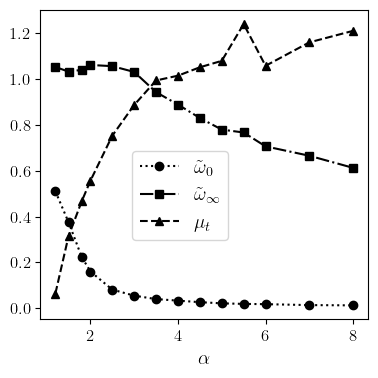

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), sharex=True)

list_linestyle = [':', '-.', '--']
list_markers = ['o', 's', '^']

for i, param_name in enumerate([r'$\tilde{\omega}_0$', r'$\tilde{\omega}_\infty$', r'$\mu_t$']):
# for i, param_name in enumerate(['A', 'B']):
    param_values = [all_fit_parameters[alpha][i] for alpha in aspect_ratios[:]]
    betas = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
    ax.plot(
        aspect_ratios[:],
        # betas[1:],
        param_values,
        'k',
        linestyle = list_linestyle[i],
        marker = list_markers[i],
        label=param_name
    )

    # add error bars
    error_values = [error_bars[alpha][i] for alpha in aspect_ratios[:]]
    ax_i.errorbar(
        aspect_ratios[:],
        param_values,
        yerr=error_values,
        fmt='o',
        color ='k',
        capsize=5,
        # color='blue'
    )

    ax_i.set_xlabel('$\\alpha$')
    ax_i.set_ylabel(param_name)
    ax_i.grid(True)

plt.xlabel('$\\alpha$')
plt.legend(loc='center left', bbox_to_anchor=(0.25, 0.4))
plt.tight_layout()
plt.savefig("Figures/fit_parameters_vs_alpha.pdf", dpi=300, bbox_inches='tight')

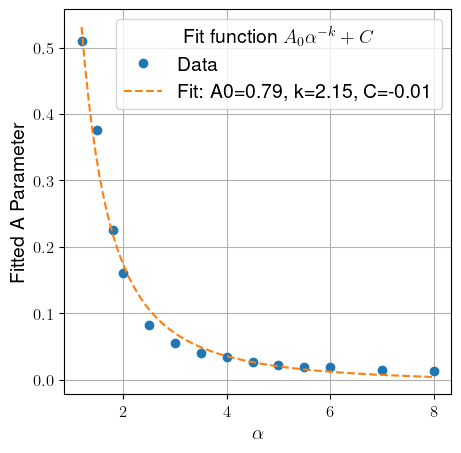

In [29]:
# fir the decay of A with alpha with an exponential function
def exponential_decay(x, A0, tau, C):
    return A0 * np.exp(-x / tau) + 0.0

def power_law_decay(x, A0, k, C):
    return A0 * x**(-k) + C

alpha_vals = aspect_ratios[:]
A_values = all_fit_parameters_array[:, 0]

popt_exp, pcov_exp = curve_fit(
    power_law_decay,
    alpha_vals[:],
    A_values[:],
    p0=[A_values[0], 5.0, 0.0]
)

# plot the fit
plt.figure(figsize=(5, 5))
plt.plot(
    alpha_vals,
    A_values,
    'o',
    label='Data'
)
alpha_fit = np.linspace(min(alpha_vals), max(alpha_vals), 100)
plt.plot(
    alpha_fit,
    power_law_decay(alpha_fit, *popt_exp),
    '--',
    label=f'Fit: A0={popt_exp[0]:.2f}, k={popt_exp[1]:.2f}, C={popt_exp[2]:.2f}'
)
plt.xlabel('$\\alpha$')
plt.ylabel('Fitted A Parameter')
plt.legend(title= "Fit function $A_0 \\alpha^{-k} + C$")
plt.grid(True)


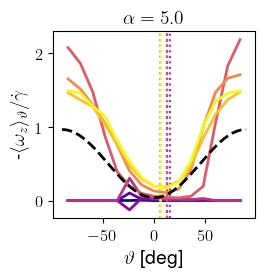

In [30]:
alpha_indexs = [9]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(3*n_plots, 3), sharey=True)

if len(alpha_indexs) == 1:
    ax = [ax]  # Make ax iterable

for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        i_cof = np.where(cofs == cof_val)[0][0]

        thetas = theta_bins[i_cof, 0, alpha_index, :] * 180/np.pi
        omega_theta = omega_bins[i_cof, 0, alpha_index, :]
        std_omega_theta = std_omega_bins[i_cof, 0, alpha_index, :] / shear_rates[i_cof, 0, alpha_index]
        ax[i].plot(
            thetas,
            -omega_theta,
            '-',
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 2.0, 
        )
        # ax[i].errorbar(thetas, omega_theta, std_omega_theta, mfc=colors_cof[i_cof],mec=colors_cof[i_cof],
        #          ecolor=colors_cof[i_cof], fmt='o', capsize=5, linestyle='None', linewidth=0.5)
        theta_d[i_cof, 0, alpha_index] = theta_d[i_cof, 0, alpha_index] if theta_d[i_cof, 0, alpha_index] >0 else theta_d[i_cof, 0, alpha_index] + np.pi
        ax[i].axvline(theta_d[i_cof, 0, alpha_index]*180/np.pi, color=colors_cof[i_cof], linestyle=':', label="$\\eta$")


    beta = (alpha_values[i]**2 - 1) / (alpha_values[i]**2 + 1)
    theta_fit = np.linspace(-np.pi/2, np.pi/2, 200)
    jeffrey_omega = -(1 - beta * np.cos(2 * theta_fit)) / 2
    theta_fit = theta_fit * 180/np.pi

    ax[i].plot(
        theta_fit,
        -jeffrey_omega,
        'k--',
        label='Jeffrey',
        linewidth=2
    )
    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")

    ax[i].set_xlabel("$\\vartheta$ [deg]")
    
ax[0].set_ylabel("-$\\langle \\omega_z \\rangle_\\vartheta  /\\dot \\gamma $")
fig.tight_layout()
fig.savefig(f"Figures/avg_omega_bin.pdf", dpi=300, bbox_inches='tight')


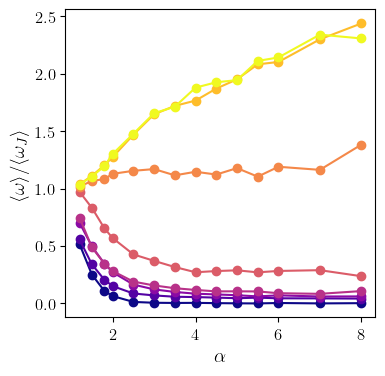

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ratio_omega = np.zeros((len(cofs), 1, len(aspect_ratios)))


for i_cof, cof_val in enumerate(cofs):
   
    for j, alpha in enumerate(aspect_ratios):
        beta = (alpha**2 - 1) / (alpha**2 + 1)
        jeffrey_value = shear_rates[i_cof, 0, j] / 2 * np.sqrt(1 - beta**2)
        ratio_omega[i_cof, 0, j] =  - omega[i_cof, 0, j, 2]  / jeffrey_value

    ax.plot(
        aspect_ratios,
        ratio_omega[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\langle \\omega \\rangle / \\langle \\omega_{{J}} \\rangle$")
# ax.set_ylabel("$2\omega_z \\sqrt{1-\\beta^2} /\dot\gamma$")
# ax.grid(True)
plt.savefig(f"Figures/omega_vs_jeffrey_total.png", dpi=300, bbox_inches='tight')

/tmp/ipykernel_47779/2169554291.py:19: RuntimeWarning: divide by zero encountered in divide
  Pis[i_cof, 0, :] = Pe / (U1_theoretical[i_cof, 0, :] * S2_scalar_theoretical[i_cof, 0, :])


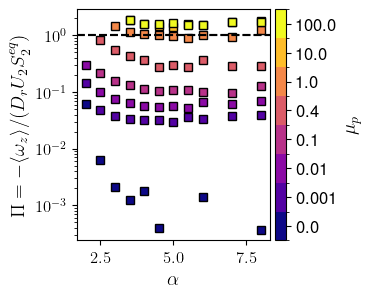

In [32]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(3, 3), sharey=True)

# if ax is not iterable, make it iterable
if not isinstance(ax, np.ndarray):
    ax = [ax]

beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
Pis = np.zeros((len(cofs), 1, len(aspect_ratios)))
for i_cof, cof_val in enumerate(cofs):
    Pe = (-omega[i_cof, 0, :, 2] ) / (D_r[i_cof, 0, :]) 
    # Pe = central_omega_norm[i_cof, :]
    U1_curr = U1_theoretical[i_cof, 0, :]
    S2_curr = S2_scalar_theoretical[i_cof, 0, :]
    S2_mask = S2_curr * U1_curr < 1.0
    Pis[i_cof, 0, :] = Pe / (U1_theoretical[i_cof, 0, :] * S2_scalar_theoretical[i_cof, 0, :])
    Pis[i_cof, 0, S2_mask] = np.nan
    Pe[~S2_mask] = np.nan

    ax[0].plot(
        aspect_ratios,
        Pis[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        markeredgecolor='k',
    )

# ax.set_xlabel(f"$\\alpha$")
ax[0].set_xlabel("$\\alpha$")
# ax.set_ylabel("$\\chi Pe/ 6 U S_2$")
ax[0].set_ylabel("$\\Pi = - \\langle \\omega_z \\rangle / (D_r U_2 S_2^{eq})$")
# ax.set_ylabel("$\\Pi =  \\chi (1 -S_2)/ ( C U S_2)$")
ax[0].set_yscale('log')

ax[0].axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="$\\Pi = 1$")

cmap_discrete = mcolors.ListedColormap(colors_cof)

bounds = np.arange(len(cofs) + 1)
norm = mcolors.BoundaryNorm(bounds, cmap_discrete.N)

sm = cm.ScalarMappable(cmap=cmap_discrete, norm=norm)

cbar = fig.colorbar(sm, ax=ax[0], pad=0.02)

cbar.set_ticks(np.arange(len(cofs)) + 0.5)
cbar.set_ticklabels([str(val) for val in cofs])
cbar.set_label("$\\mu_p$") # Or whichever label you prefer for friction
# ax.set_xlim(2.5, 8.1)
ax[0].axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="$\\Pi = 1$")
fig.savefig(f"Figures/Pi_vs_alpha_I_{I}.pdf", dpi=300, bbox_inches='tight')

/tmp/ipykernel_47779/3981127411.py:70: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-.1, 3)


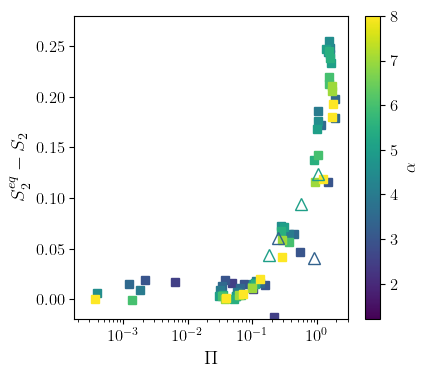

In [33]:
Pis_rods = np.array([[[9.72728802e+01, 2.44844449e-01, 1.82242573e-01]],
 [[7.43852787e+02, 9.09277639e-01, 5.67257410e-01]],
 [[8.98287482e+02, 7.54410380e+01, 1.03988551e+00]]]
)

biaxiality_rods = np.array([[[0.04368842, 0.01670691, 0.00980193]],
       [[0.0767007 , 0.03985574, 0.02474923]],
       [[0.07669505, 0.05775459, 0.04556887]]])


delta_s_rods = np.array([[[ 0.70095522, -0.06069196, -0.04359215]],
 [[ 0.50895832, -0.04028581, -0.09397234]],
 [[ 0.38506512,  0.60996797, -0.12335939]]])



rod_alphas = np.array([2.0, 3.3, 5.0])

spheroid_alphas_to_plot = aspect_ratios[aspect_ratios > 1.0]  # Filter for spheroids with alpha > 2.0

# Combine all alphas to find the true min/max for the colormap
all_alphas = np.union1d(spheroid_alphas_to_plot, rod_alphas)
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=all_alphas.min(), vmax=all_alphas.max())

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4))


# --- 2. Plot Spheroids (Your original loop, modified) ---
for alpha in spheroid_alphas_to_plot:
    i_alpha_spheroid = np.where(aspect_ratios == alpha)[0][0]
    beta_i = (alpha**2 - 1) / (alpha**2 + 1)
    # b_jeffrey = biax_jeffrey(alpha)
    biaxiality_talbot = intepolator(biax_no_noise[:, 0], biax_no_noise[:, 1])(beta_i)
    Pe = -omega[i_cof, 0, i_alpha_spheroid, 2] / D_r[i_cof, 0, i_alpha_spheroid]
    ax.semilogx(
        Pis[:, 0, i_alpha_spheroid],  # Use the pre-calculated Pi
        # np.abs(S2_scalar[:, 0, i_alpha_spheroid] - S2_scalar_theoretical[:, 0, i_alpha_spheroid]) / S2_scalar[:, 0, i_alpha_spheroid],  # Normalized biaxiality
        -(S2_scalar[:, 0, i_alpha_spheroid] - S2_scalar_theoretical[:, 0, i_alpha_spheroid]),  
        's',  # Square marker for spheroids
        # label=f"Spheroid $\\alpha={alpha:.1f}$",
        color=cmap(norm(alpha)),  # Get color from normalized map
        alpha=1.0 #if alpha >= 3.0 else 0.4  # Different alpha for visibility
    )

# #-- 3. Plot Rods (New loop) ---
for i_alpha_rod, alpha in enumerate(rod_alphas):
    ax.plot(
        Pis_rods[:, 0, i_alpha_rod],
        -delta_s_rods[:, 0, i_alpha_rod],
        '^',  # Triangle marker for rods
        markersize=8,
        label=f"${alpha:.1f}$",
        color=cmap(norm(alpha)),  # Get color from the SAME map
        alpha=1.0,
        mfc='none' # Use a hollow marker to distinguish further
    )

# add colorbar for the aspect ratio
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\alpha$", fontsize=12)

# ax.legend(title= r"Rod $\alpha=$", bbox_to_anchor=(.45, .5), fontsize=12)
ax.set_xlabel("$\\Pi$")
# ax.set_ylabel("$\\lambda_2- \\lambda_3$")
ax.set_ylabel("$S_2^{{eq}} - S_2$")  # Relative error in S2

plt.ylim(-0.02, 0.28)
ax.set_xlim(-.1, 3)
plt.tight_layout()
plt.savefig(f"Figures/delta_s2_vs_Pi_all.pdf", dpi=300, bbox_inches='tight')
plt.show()

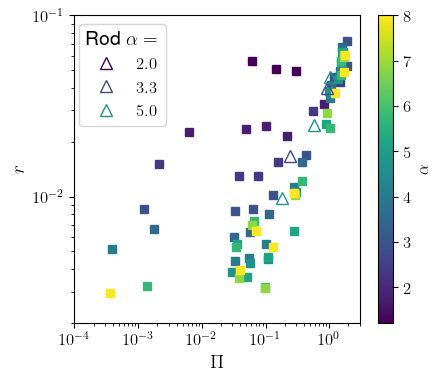

In [34]:
biaxiality_rods = np.array([[[0.04368842, 0.01670691, 0.00980193]],
       [[0.0767007 , 0.03985574, 0.02474923]],
       [[0.07669505, 0.05775459, 0.04556887]]])

rod_alphas = np.array([2.0, 3.3, 5.0])

spheroid_alphas_to_plot = aspect_ratios[aspect_ratios >= 2.0]


# Combine all alphas to find the true min/max for the colormap
all_alphas = np.union1d(spheroid_alphas_to_plot, rod_alphas)
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=all_alphas.min(), vmax=all_alphas.max())

fig, ax = plt.subplots(1, 1, figsize=(4.6, 4))

# --- Plot Spheroids (Your original loop, modified) ---
for alpha in spheroid_alphas_to_plot:
    i_alpha_spheroid = np.where(aspect_ratios == alpha)[0][0]
    beta_i = (alpha**2 - 1) / (alpha**2 + 1)
    # b_jeffrey = biax_jeffrey(alpha)
    biaxiality_talbot = intepolator(biax_no_noise[:, 0], biax_no_noise[:, 1])(beta_i)
    Pe = -omega[i_cof, 0, i_alpha_spheroid, 2] / D_r[i_cof, 0, i_alpha_spheroid]
    Pe = Pe**1
    ax.loglog(
        Pis[:, 0, i_alpha_spheroid],  # Use the pre-calculated Pi
        biaxiality[:, 0, i_alpha_spheroid], 
        's',  # Square marker for spheroids
        # label=f"Spheroid $\\alpha={alpha:.1f}$",
        color=cmap(norm(alpha)),  # Get color from normalized map
        alpha=1.0 #if alpha >= 3.0 else 0.4  # Different alpha for visibility
    )

# #-- Plot Rods (New loop) ---
for i_alpha_rod, alpha in enumerate(rod_alphas):
    ax.loglog(
        Pis_rods[:, 0, i_alpha_rod],
        biaxiality_rods[:, 0, i_alpha_rod],
        '^',  # Triangle marker for rods
        markersize=8,
        label=f"${alpha:.1f}$",
        color=cmap(norm(alpha)),  # Get color from the SAME map
        alpha=1.0,
        mfc='none' # Use a hollow marker to distinguish further
    )

ax.legend(title= r"Rod $\alpha=$", bbox_to_anchor=(.35, 1.0), fontsize=12)
ax.set_xlabel("$\\Pi$")
ax.set_ylabel("$r$")
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\alpha$", fontsize=12)
# ax.set_ylabel("$|S_2 - S_2^{{eq}}| / S_2$")  # Relative error in S2
plt.ylim(0.002, 0.1)
ax.set_xlim(0.0001, 3)
plt.savefig(f"Figures/biaxiality_vs_Pi.pdf", dpi=300, bbox_inches='tight')
plt.show()

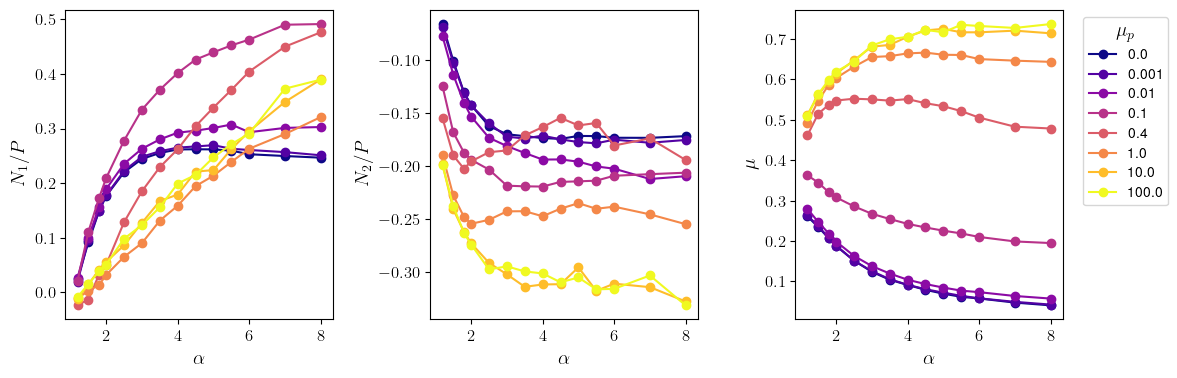

In [35]:
#plot n1_diff and n2_diff as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i_cof, cof_val in enumerate(cofs):
    ax[0].plot(
        aspect_ratios,
        n1_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
    ax[1].plot(
        aspect_ratios,
        n2_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
    ax[2].plot(
        aspect_ratios,
        p_xy[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )


ax[0].set_xlabel(f"$\\alpha$")
ax[0].set_ylabel("$N_1/P$")
ax[1].set_xlabel(f"$\\alpha$")
ax[1].set_ylabel("$N_2/P$")
ax[2].set_xlabel(f"$\\alpha$")
ax[2].set_ylabel("$\\mu$")
ax[2].legend(title="$\\mu_p$", bbox_to_anchor=(1.05, 1.0), fontsize=10)
fig.tight_layout()


In [36]:
n_densities = 50 
n_aps = 50

densities = np.linspace(0.01, 0.95, n_densities) 
aps = np.linspace(1.1, 8.0, n_aps)

S2_map = np.zeros((n_aps, n_densities))

for i, ap in enumerate(aps):
    # Set a small initial seed for the lowest density of each aspect ratio
    current_guess = (0.2, 0.2) 
    
    for j, density in enumerate(densities):
        correction_density = compute_vega_correction_density(ap, density)

        U_test_2 = correction_density * parsons_volume_approx_p2(ap)
        U_test_4 = correction_density * parsons_volume_approx_p4(ap)

        # Solve for theoretical S2 and S4
        S2, S4 = solve_self_consistent_S2_S4_p4(
            (U_test_2, U_test_4),
            initial_guesses=current_guess
        )
        
        S2_map[i, j] = S2
        
        current_guess = (max(0.05, S2), S4)

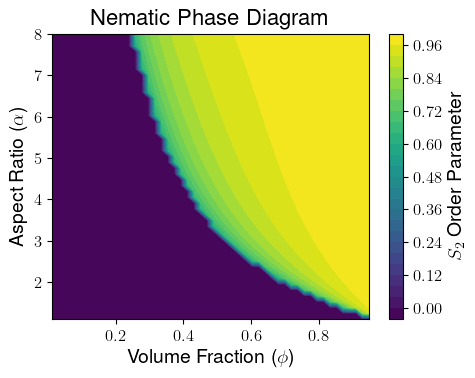

In [37]:
plt.figure(figsize=(5, 4))

# Create a meshgrid for the X and Y axes
X, Y = np.meshgrid(densities, aps)

# Use contourf for a smooth, interpolated map, or pcolormesh for exact grid pixels
cp = plt.contourf(X, Y, S2_map, levels=30, cmap='viridis')
cbar = plt.colorbar(cp)
cbar.set_label("$S_2$ Order Parameter", fontsize=14)

plt.xlabel("Volume Fraction ($\\phi$)", fontsize=14)
plt.ylabel("Aspect Ratio ($\\alpha$)", fontsize=14)
plt.title("Nematic Phase Diagram", fontsize=16)

# Optional: Add a line denoting the Isotropic-Nematic transition boundary
# plt.contour(X, Y, S2_map, levels=[0.1], colors='red', linestyles='dashed')

plt.tight_layout()
plt.show()